# Library and Data Imports and Standardization

In [1]:
# Make the imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import sklearn as sk

# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Import ordinal encoder
from sklearn.preprocessing import OrdinalEncoder

# Import Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Import train test split
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn import svm
from sklearn.kernel_approximation import RBFSampler
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import classification_report, accuracy_score, f1_score, r2_score, root_mean_squared_error

# Import KFold
from sklearn.model_selection import KFold

# Import log2
import math

# Import pprint
from pprint import pprint

from matplotlib.cm import get_cmap
cmap = get_cmap('hot')
middle_color = cmap(0.5)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
oaa_ridge_forward_features = ['Parent tweets',
 'Replies to parents',
 'Parent tweets with replies',
 'Toxic parent tweets',
 'Toxic replies',
 'Toxic replies to non-toxic parents',
 'Toxic replies to toxic parents',
 'Friends_count',
 'Listed_count',
 'Verified',
 'Statuses_count',
 'Retweet_count avg',
 'Retweet_count max',
 'Favorite_count min',
 'Repliers with min 1 toxic reply',
 'High toxicity parents',
 'High identity_attack parents',
 'High insult parents',
 'High profanity parents',
 'High threat parents',
 'High toxicity replies',
 'High identity_attack replies',
 'High insult replies',
 'High profanity replies',
 'High threat replies',
 '<3 replies parents',
 '>=3 replies parents',
 'Love',
 'Feminist',
 'Toxicity']

In [3]:
# Import the datasets
convabuse = pd.read_csv('/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/convabuse_final.csv')
dynamically_generated_hate_speech = pd.read_csv('/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/dynamically_generated_hate_speech_dataset_final.csv')
online_abusive_attacks = pd.read_csv('/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/online_abusive_attacks_class_final.csv')
us_elections_2020_hate_speech = pd.read_csv('/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/us_elections_2020_hate_speech_final.csv')
mlma_hate_speech = pd.read_csv('/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/MLMA_hate_speech_final.csv')

In [4]:
convabuse.head()

,annotator_id,bot,generalised,individual,system,explicit,implicit,abuse_level,target_groups
0,2,1,0,0,0,0,0,0,0
1,7,1,0,0,0,0,0,0,0
2,5,0,0,0,0,0,0,0,0
3,5,0,0,0,0,0,0,0,0
4,3,1,0,0,0,0,0,0,0


In [5]:
convabuse_X = convabuse.drop("abuse_level", axis=1)
convabuse_y = convabuse["abuse_level"]

In [6]:
dynamically_generated_hate_speech.head()

,label,type,annotator,target_groups,original
0,1.0,-1,4,0,1
1,1.0,-1,9,1,1
2,1.0,-1,16,1,0
3,1.0,0,2,0,1
4,1.0,-1,15,0,1


In [7]:
dghs_X = dynamically_generated_hate_speech.drop("label", axis=1)
dghs_y = dynamically_generated_hate_speech["label"]

In [8]:
online_abusive_attacks.head()

,index,Toxic parent tweets,Toxic replies,Toxic Level
0,0,0.0,0.0,0
1,5,0.0,0.0,0
2,6,0.0,0.0,0
3,10,0.0,0.0,0
4,11,0.0,0.0,0


In [9]:
oaa_X = online_abusive_attacks.drop("Toxic Level", axis=1)
oaa_y = online_abusive_attacks["Toxic Level"]

In [10]:
us_elections_2020_hate_speech.head()

,Trump,Biden,West,HOF
0,-1,0,1,1
1,1,0,1,1
2,1,0,1,1
3,-1,0,1,1
4,0,-1,1,1


In [11]:
us2020hs_X = us_elections_2020_hate_speech.drop("HOF", axis=1)
us2020hs_y = us_elections_2020_hate_speech["HOF"]

In [12]:
mlma_hate_speech.head()

,index,implicit,explicit,target_groups,annotator_sentiment,abuse_level
0,1861,1,0,0,2,1
1,17955,1,0,0,2,1
2,15485,1,0,0,2,1
3,1015,1,0,0,0,1
4,16627,1,0,0,1,1


In [13]:
mlma_hate_speech_X = mlma_hate_speech.drop(columns=["target_groups", "index"], axis=1)
mlma_hate_speech_y = mlma_hate_speech["target_groups"]

# Linear Modeling

In [14]:
# Get only the numeric features for each dataset
convabuse_X_numeric = convabuse_X.select_dtypes(include=np.number)
dghs_X_numeric = dghs_X.select_dtypes(include=np.number)
oaa_X_numeric = oaa_X.select_dtypes(include=np.number)
us2020hs_X_numeric = us2020hs_X.select_dtypes(include=np.number)
mlma_hate_speech_X_numeric = mlma_hate_speech_X.select_dtypes(include=np.number)

In [15]:
# Use standard scaler on the Convabuse data
convabuse_scaler = StandardScaler()
convabuse_X_scaled = convabuse_scaler.fit_transform(convabuse_X_numeric)
convabuse_X_scaled = pd.DataFrame(convabuse_X_scaled, columns=convabuse_X_numeric.columns)

In [16]:
# Use standard scaler on the Dynamically Generated Hate Speech X data
dghs_scaler = StandardScaler()
dghs_X_scaled = dghs_scaler.fit_transform(dghs_X_numeric)
dghs_X_scaled = pd.DataFrame(dghs_X_scaled, columns=dghs_X_numeric.columns)

In [17]:
# Use standard scaler on the Online Abusive Attacks X data
oaa_scaler = StandardScaler()
oaa_X_scaled = oaa_scaler.fit_transform(oaa_X_numeric)
oaa_X_scaled = pd.DataFrame(oaa_X_scaled, columns=oaa_X_numeric.columns)

In [18]:
# Use standard scaler on the US elections 2020 hate speech X data
us2020hs_scaler = StandardScaler()
us2020hs_X_scaled = us2020hs_scaler.fit_transform(us2020hs_X_numeric)
us2020hs_X_scaled = pd.DataFrame(us2020hs_X_scaled, columns=us2020hs_X_numeric.columns)

In [19]:
# Use standard scaler on the MLMA hate speech X data
mlma_hate_speech_scaler = StandardScaler()
mlma_hate_speech_X_scaled = mlma_hate_speech_scaler.fit_transform(mlma_hate_speech_X_numeric)
mlma_hate_speech_X_scaled = pd.DataFrame(mlma_hate_speech_X_scaled, columns=mlma_hate_speech_X_numeric.columns)

In [20]:
for columns in [convabuse_X_numeric.columns, dghs_X_numeric.columns, oaa_X_numeric.columns, us2020hs_X_numeric.columns, mlma_hate_speech_X_numeric]:
  print(columns)

Index(['annotator_id', 'bot', 'generalised', 'individual', 'system',
       'explicit', 'implicit', 'target_groups'],
      dtype='object')
Index(['type', 'annotator', 'target_groups', 'original'], dtype='object')
Index(['index', 'Toxic parent tweets', 'Toxic replies'], dtype='object')
Index(['Trump', 'Biden', 'West'], dtype='object')
       implicit  explicit  annotator_sentiment  abuse_level
0             1         0                    2            1
1             1         0                    2            1
2             1         0                    2            1
3             1         0                    0            1
4             1         0                    1            1
...         ...       ...                  ...          ...
21671         1         0                    3            1
21672         1         0                    1            1
21673         1         0                    4            1
21674         1         0                    2            1
216

In [21]:
# Train test split for each dataset
convabuse_X_train, convabuse_X_test, convabuse_y_train, convabuse_y_test = train_test_split(convabuse_X_scaled, convabuse_y, test_size=0.2, random_state=42, stratify=convabuse_y)
dghs_X_train, dghs_X_test, dghs_y_train, dghs_y_test = train_test_split(dghs_X_scaled, dghs_y, test_size=0.2, random_state=42, stratify=dghs_y)
oaa_X_train, oaa_X_test, oaa_y_train, oaa_y_test = train_test_split(oaa_X_scaled, oaa_y, test_size=0.2, random_state=42)
us2020hs_X_train, us2020hs_X_test, us2020hs_y_train, us2020hs_y_test = train_test_split(us2020hs_X_scaled, us2020hs_y, test_size=0.2, random_state=42, stratify=us2020hs_y)
mlma_hate_speech_X_train, mlma_hate_speech_X_test, mlma_hate_speech_y_train, mlma_hate_speech_y_test = train_test_split(mlma_hate_speech_X_scaled, mlma_hate_speech_y, test_size=0.2, random_state=42, stratify=mlma_hate_speech_y)

In [22]:
# Get the max iteration based on log 2
convabuse_max_iter = int(np.ceil(np.log2(len(convabuse_X_train))))
dghs_max_iter = int(np.ceil(np.log2(len(dghs_X_train))))
oaa_max_iter = int(np.ceil(np.log2(len(oaa_X_train))))
us2020hs_max_iter = int(np.ceil(np.log2(len(us2020hs_X_train))))
mlma_hate_speech_max_iter = int(np.ceil(np.log2(len(mlma_hate_speech_X_train))))

In [23]:
svm_classification_results_list = []
svm_regression_results_list = []

In [24]:
# Setup KFold for each dataset's model
convabuse_kfold = KFold(n_splits=5, shuffle=True, random_state=42)
dghs_kfold = KFold(n_splits=5, shuffle=True, random_state=42)
oaa_kfold = KFold(n_splits=5, shuffle=True, random_state=42)
us2020hs_kfold = KFold(n_splits=5, shuffle=True, random_state=42)
mlma_hate_speech_kfold = KFold(n_splits=5, shuffle=True, random_state=42)

In [25]:
# Loop through the parameter grid and train the SVM model
def svm_grid_search(X_train, X_test, y_train, y_test, param_grid, kfold, model_name):
    """Train an SVM model using GridSearchCV and print the classification report."""
    # Create the SVM model
    svm_model = svm.SVC()

    # Create the GridSearchCV object
    grid_search = GridSearchCV(svm_model, param_grid, cv=kfold, scoring='accuracy', verbose=1, n_jobs=-1)

    # Fit the model
    grid_search.fit(X_train, y_train)

    # Get the best model
    best_model = grid_search.best_estimator_

    # Make predictions on the test set
    y_pred = best_model.predict(X_test)

    # Print out the parameters that were tested:
    print(f"Parameters tested for {model_name}:")
    pprint(grid_search.cv_results_['params'])

    # Print the classification report
    print(f"Best parameters for {model_name}:", grid_search.best_params_)
    print("Classification report:")
    print(classification_report(y_test, y_pred))
    print(f"F1 Score: {f1_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

    return grid_search, best_model # Return the grid_search object

In [26]:
balance = "Resampled"

## Convabuse Support Vector Machines

In [27]:
# Use grid search to find the best hyperparameters for the Linear SVC model
convabuse_svm_linear_param_grid = {
    'C': np.linspace(0.1, 1, 10), # Regularization parameter
    'loss': ['squared_hinge'], # Loss function
    'max_iter': [convabuse_max_iter], #range(1, 11), # Maximum number of iterations
    'tol': [1e-4] # Tolerance for stopping criteria
}

In [28]:
convabuse_svm_linear_grid_search = GridSearchCV(svm.LinearSVC(), convabuse_svm_linear_param_grid, cv=convabuse_kfold, scoring='accuracy')
convabuse_svm_linear_grid_search.fit(convabuse_X_train, convabuse_y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LinearSVC(),
             param_grid={'C': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
                         'loss': ['squared_hinge'], 'max_iter': [15],
                         'tol': [0.0001]},
             scoring='accuracy')

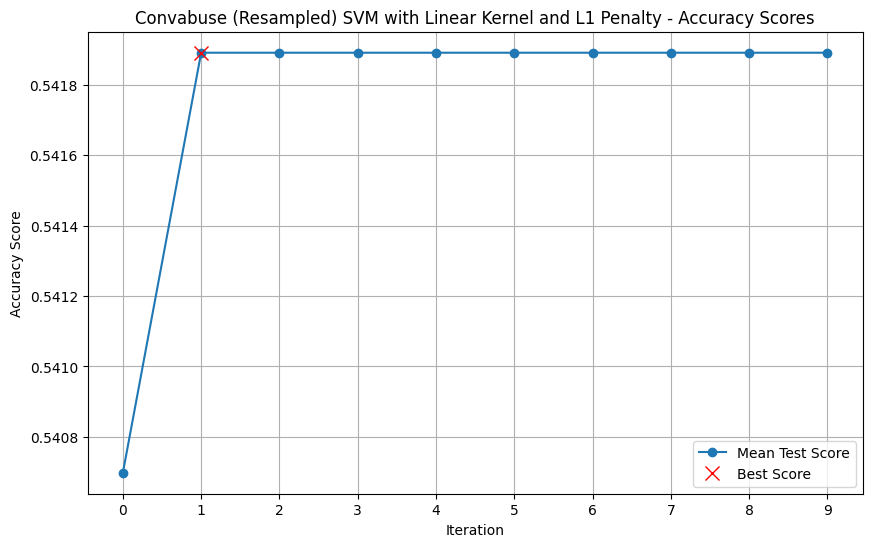

In [29]:
# Plot all accuracy scores for the SVM model with linear kernel and L1 penalty for each iteration
plt.figure(figsize=(10, 6))
plt.plot(convabuse_svm_linear_grid_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot a red x at the best score
convabuse_linear_best_score_index = np.argmax(convabuse_svm_linear_grid_search.cv_results_['mean_test_score'])
plt.plot(convabuse_linear_best_score_index, convabuse_svm_linear_grid_search.cv_results_['mean_test_score'][convabuse_linear_best_score_index], 'rx', markersize=10, label='Best Score')

plt.title(f'Convabuse ({balance}) SVM with Linear Kernel and L1 Penalty - Accuracy Scores')
plt.xlabel('Iteration')
plt.ylabel('Accuracy Score')
plt.xticks(range(len(convabuse_svm_linear_grid_search.cv_results_['mean_test_score'])))
plt.grid()
plt.legend()
plt.show()

In [30]:
# Print the best parameters and score from the grid search
print("Best parameters for SVM with linear kernel and L1 penalty:")
pprint(convabuse_svm_linear_grid_search.best_params_)
print("Best score for SVM with linear kernel and L1 penalty:")
print(convabuse_svm_linear_grid_search.best_score_)

Best parameters for SVM with linear kernel and L1 penalty:
{'C': np.float64(0.2), 'loss': 'squared_hinge', 'max_iter': 15, 'tol': 0.0001}
Best score for SVM with linear kernel and L1 penalty:
0.5418906560636183


In [31]:
# Train the SVM model with the best parameters
convabuse_svm_model_linear = svm.LinearSVC(**convabuse_svm_linear_grid_search.best_params_, random_state=42)
convabuse_svm_model_linear.fit(convabuse_X_train, convabuse_y_train)

LinearSVC(C=np.float64(0.2), max_iter=15, random_state=42)

In [32]:
# Print the classification report for the convabuse_svm_model_linear model
convabuse_y_pred_linear = convabuse_svm_model_linear.predict(convabuse_X_test)
print("Classification report for SVM with linear kernel and L1 penalty:")
print(classification_report(convabuse_y_test, convabuse_y_pred_linear))
print(f"F1 Score: {f1_score(convabuse_y_test, convabuse_y_pred_linear, average='weighted'):.4f}")
print(f"Accuracy: {accuracy_score(convabuse_y_test, convabuse_y_pred_linear):.4f}")

Classification report for SVM with linear kernel and L1 penalty:
              precision    recall  f1-score   support

           0       0.71      0.39      0.51      1006
           1       0.58      0.83      0.68      1006
           2       0.69      0.49      0.58      1006
           3       0.34      0.19      0.24      1007
           4       0.44      0.78      0.57      1006

    accuracy                           0.54      5031
   macro avg       0.55      0.54      0.51      5031
weighted avg       0.55      0.54      0.51      5031

F1 Score: 0.5138
Accuracy: 0.5357


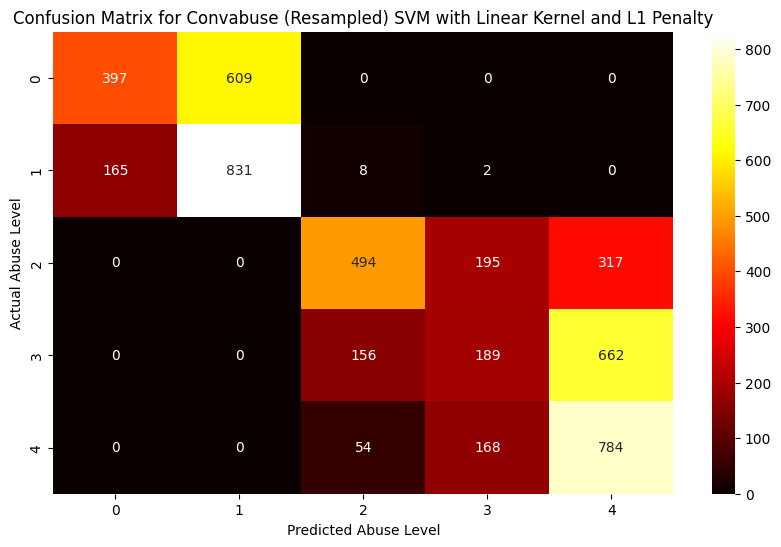

In [33]:
# Plot a heatmap of the actual vs predicted abuse levels for the convabuse_svm_model_linear model
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(convabuse_y_test, convabuse_y_pred_linear, rownames=['Actual'], colnames=['Predicted']), annot=True, fmt='d', cmap='hot')
plt.title(f'Confusion Matrix for Convabuse ({balance}) SVM with Linear Kernel and L1 Penalty')
plt.xlabel('Predicted Abuse Level')
plt.ylabel('Actual Abuse Level')
plt.show()

,feature,importance_mean,importance_std
4,system,0.117889,0.002250
6,implicit,0.102306,0.001282
5,explicit,0.079666,0.002248
1,bot,0.043590,0.004152
0,annotator_id,0.016120,0.003723
2,generalised,0.000000,0.000000
3,individual,0.000000,0.000000
7,target_groups,-0.004830,0.003242


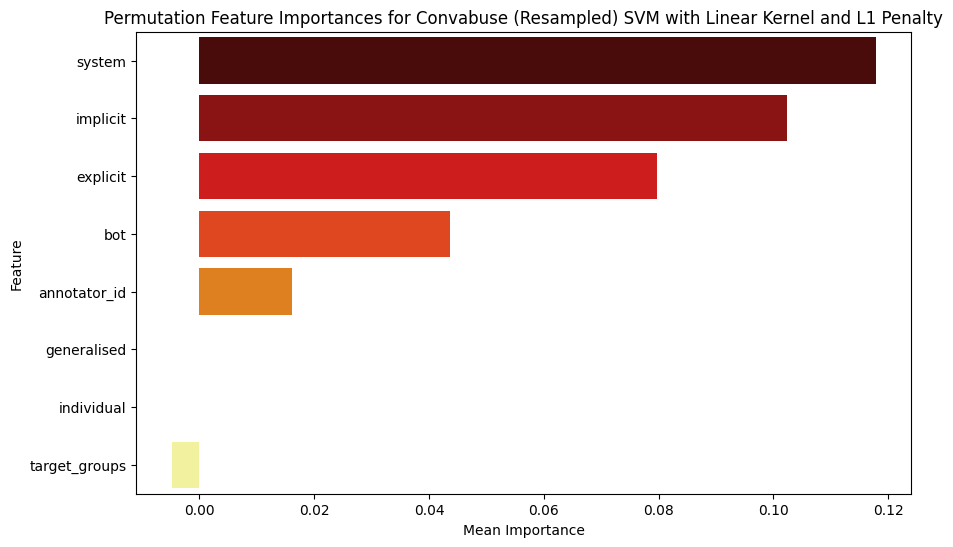

In [34]:
from sklearn.inspection import permutation_importance

# Determine the feature importances
perm_importance = permutation_importance(convabuse_svm_model_linear, convabuse_X_test, convabuse_y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Organize the results into a DataFrame
convabuse_svm_model_linear_perm_importances = pd.DataFrame({
    'feature': convabuse_X_test.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

display(convabuse_svm_model_linear_perm_importances)

# Condense into a dictionary with each feature key and importance mean value
convabuse_svm_model_linear_perm_importances_dict = convabuse_svm_model_linear_perm_importances.set_index('feature')['importance_mean'].to_dict()

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance_mean', y='feature', data=convabuse_svm_model_linear_perm_importances, palette='hot')
plt.title(f'Permutation Feature Importances for Convabuse ({balance}) SVM with Linear Kernel and L1 Penalty')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.show()

In [35]:
svm_classification_results_list.append(("Convabuse", "Linear", "L1", accuracy_score(convabuse_y_test, convabuse_y_pred_linear), f1_score(convabuse_y_test, convabuse_y_pred_linear, average='weighted'), convabuse_svm_model_linear_perm_importances_dict))

In [36]:
convabuse_svm_rbf_pipeline = Pipeline([
    ("kernel", RBFSampler()),
    ("clf", SGDClassifier(loss="hinge", random_state=42, penalty="l2", tol=1e-4))
])

In [37]:
# Use grid search to find the best hyperparameters for the SVM model
convabuse_svm_rbf_param_grid = {
    'kernel__gamma': np.linspace(0.1, 1, 10), # Kernel coefficient,
    'kernel__n_components': range(2, convabuse_X_train.shape[1] + 1), # Number of components for the RBF kernel
    'clf__alpha': [1e-4], # Regularization parameter
    'clf__max_iter': [convabuse_max_iter], # range(330, 350), # Maximum number of iterations
    'clf__tol': [1e-4], # Tolerance for stopping criteria
    'clf__early_stopping': [True] # Whether to use early stopping
}

In [38]:
# Perform a grid search using the RBFSampler
convabuse_svm_rbf_grid_search = GridSearchCV(
    estimator=convabuse_svm_rbf_pipeline,
    param_grid=
    convabuse_svm_rbf_param_grid,
    cv=convabuse_kfold,
    scoring='accuracy',
    n_jobs=2,
    verbose=True
)

In [39]:
# Fit the grid search to the training data
convabuse_svm_rbf_grid_search.fit(convabuse_X_train, convabuse_y_train)

Fitting 5 folds for each of 70 candidates, totalling 350 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('kernel', RBFSampler()),
                                       ('clf',
                                        SGDClassifier(random_state=42,
                                                      tol=0.0001))]),
             n_jobs=2,
             param_grid={'clf__alpha': [0.0001], 'clf__early_stopping': [True],
                         'clf__max_iter': [15], 'clf__tol': [0.0001],
                         'kernel__gamma': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
                         'kernel__n_components': range(2, 9)},
             scoring='accuracy', verbose=True)

In [40]:
# Print the best parameters and score from the grid search
print("Best parameters for SVM with RBF kernel:")
pprint(convabuse_svm_rbf_grid_search.best_params_)
print("Best score for SVM with RBF kernel:")
print(convabuse_svm_rbf_grid_search.best_score_)

Best parameters for SVM with RBF kernel:
{'clf__alpha': 0.0001,
 'clf__early_stopping': True,
 'clf__max_iter': 15,
 'clf__tol': 0.0001,
 'kernel__gamma': np.float64(0.1),
 'kernel__n_components': 8}
Best score for SVM with RBF kernel:
0.5388092686119309


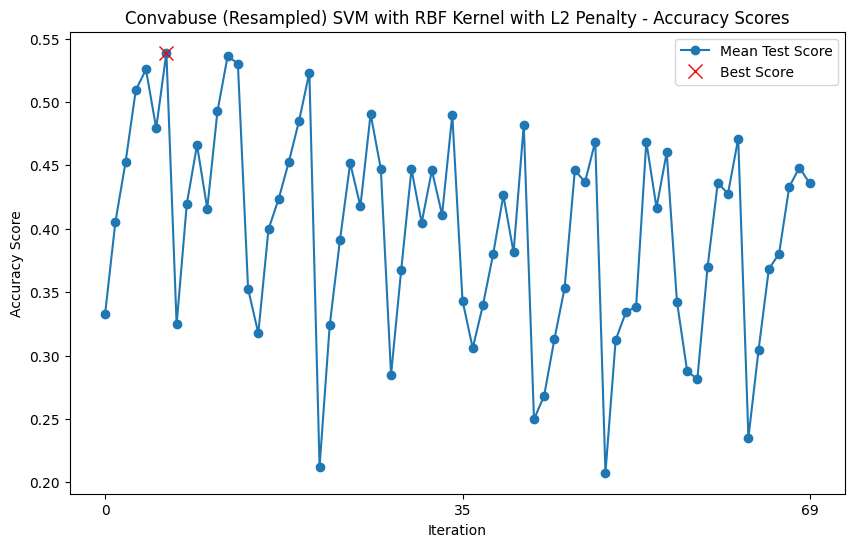

In [41]:
# Plot all accuracy scores for the SVM model with RBF kernel for each iteration
plt.figure(figsize=(10, 6))
plt.plot(convabuse_svm_rbf_grid_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot a red x at the best score
best_convabuse_svm_rbf_score_index = np.argmax(convabuse_svm_rbf_grid_search.cv_results_['mean_test_score'])
plt.plot(best_convabuse_svm_rbf_score_index, convabuse_svm_rbf_grid_search.cv_results_['mean_test_score'][best_convabuse_svm_rbf_score_index], 'rx', markersize=10, label='Best Score')

plt.title(f'Convabuse ({balance}) SVM with RBF Kernel with L2 Penalty - Accuracy Scores')
plt.xlabel('Iteration')
plt.ylabel('Accuracy Score')

# Only plot x-axis ticks of 0, the median, and the last iteration
plt.xticks([0, len(convabuse_svm_rbf_grid_search.cv_results_['mean_test_score']) // 2, len(convabuse_svm_rbf_grid_search.cv_results_['mean_test_score']) - 1])

plt.legend()
plt.show()

In [42]:
# Train the SVM model with the best parameters
convabuse_svm_model_rbf = convabuse_svm_rbf_grid_search.best_estimator_
convabuse_svm_model_rbf.fit(convabuse_X_train, convabuse_y_train)

Pipeline(steps=[('kernel', RBFSampler(gamma=np.float64(0.1), n_components=8)),
                ('clf',
                 SGDClassifier(early_stopping=True, max_iter=15,
                               random_state=42, tol=0.0001))])

In [43]:
# Print the classification report for the convabuse_svm_model_rbf model
convabuse_y_pred_rbf = convabuse_svm_model_rbf.predict(convabuse_X_test)
print("Classification report for SVM with RBF kernel:")
print(classification_report(convabuse_y_test, convabuse_y_pred_rbf))
print(f"F1 Score: {f1_score(convabuse_y_test, convabuse_y_pred_rbf, average='weighted'):.4f}")
print(f"Accuracy: {accuracy_score(convabuse_y_test, convabuse_y_pred_rbf):.4f}")

Classification report for SVM with RBF kernel:
              precision    recall  f1-score   support

           0       0.62      0.50      0.56      1006
           1       0.59      0.68      0.63      1006
           2       0.66      0.44      0.53      1006
           3       0.37      0.22      0.28      1007
           4       0.47      0.83      0.60      1006

    accuracy                           0.54      5031
   macro avg       0.54      0.54      0.52      5031
weighted avg       0.54      0.54      0.52      5031

F1 Score: 0.5191
Accuracy: 0.5359


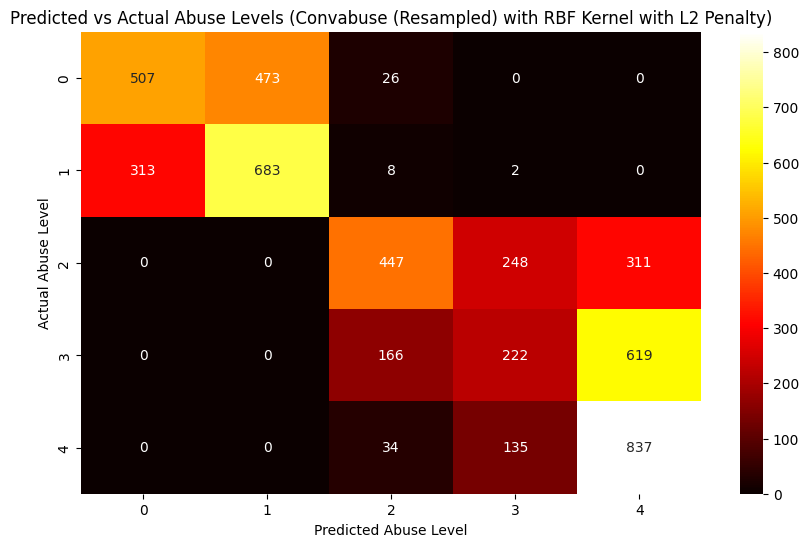

In [44]:
# Plot a heatmap of the predicted vs actual abuse levels
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(convabuse_y_test, convabuse_y_pred_rbf), annot=True, fmt='d', cmap='hot')
plt.title(f'Predicted vs Actual Abuse Levels (Convabuse ({balance}) with RBF Kernel with L2 Penalty)')
plt.xlabel('Predicted Abuse Level')
plt.ylabel('Actual Abuse Level')
plt.show()

,feature,importance_mean,importance_std
4,system,0.223932,0.004158
5,explicit,0.085470,0.005047
7,target_groups,0.060227,0.004102
6,implicit,0.058438,0.001841
0,annotator_id,0.038501,0.003313
1,bot,0.031723,0.002825
3,individual,0.000000,0.000000
2,generalised,0.000000,0.000000


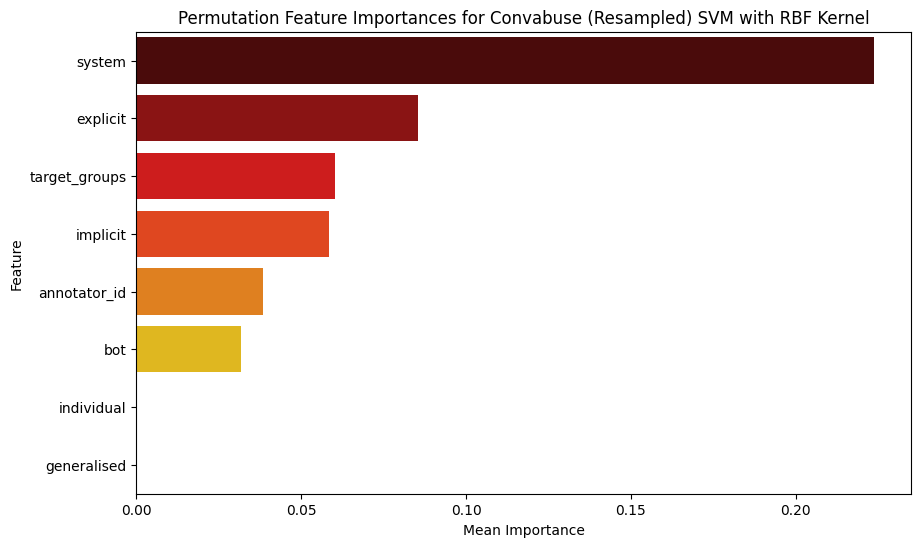

In [45]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance for the RBF kernel SVM model
perm_importance = permutation_importance(convabuse_svm_model_rbf, convabuse_X_test, convabuse_y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Organize the results into a DataFrame
convabuse_svm_rbf_perm_importance = pd.DataFrame({
    'feature': convabuse_X_test.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

display(convabuse_svm_rbf_perm_importance)

# Condense into a dictionary with each feature key and importance mean value
convabuse_svm_rbf_perm_importances_dict = convabuse_svm_rbf_perm_importance.set_index('feature')['importance_mean'].to_dict()

# Plot the permutation importance
plt.figure(figsize=(10, 6))
sns.barplot(x='importance_mean', y='feature', data=convabuse_svm_rbf_perm_importance, palette='hot')
plt.title(f'Permutation Feature Importances for Convabuse ({balance}) SVM with RBF Kernel')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.show()

In [46]:
svm_classification_results_list.append(("Convabuse", "RBF", "L2", accuracy_score(convabuse_y_test, convabuse_y_pred_rbf), f1_score(convabuse_y_test, convabuse_y_pred_rbf, average='weighted'), convabuse_svm_rbf_perm_importances_dict))

In [47]:
convabuse_custom_param_grid = {
    "C": np.linspace(0.1, 1, 10),
    "kernel": ["linear"],
    "max_iter": range(1, convabuse_max_iter), # range(2960, 3000),
    "class_weight": ["balanced"]
}

In [48]:
# Train and evaluate the SVM model on the US Accidents Upsampled dataset
convabuse_custom_svm_grid_search, convabuse_custom_svm_model = svm_grid_search(convabuse_X_train, convabuse_X_test, convabuse_y_train, convabuse_y_test, convabuse_custom_param_grid, convabuse_kfold, "convabuse_custom_svm_model")

Fitting 5 folds for each of 140 candidates, totalling 700 fits
Parameters tested for convabuse_custom_svm_model:
[{'C': np.float64(0.1),
  'class_weight': 'balanced',
  'kernel': 'linear',
  'max_iter': 1},
 {'C': np.float64(0.1),
  'class_weight': 'balanced',
  'kernel': 'linear',
  'max_iter': 2},
 {'C': np.float64(0.1),
  'class_weight': 'balanced',
  'kernel': 'linear',
  'max_iter': 3},
 {'C': np.float64(0.1),
  'class_weight': 'balanced',
  'kernel': 'linear',
  'max_iter': 4},
 {'C': np.float64(0.1),
  'class_weight': 'balanced',
  'kernel': 'linear',
  'max_iter': 5},
 {'C': np.float64(0.1),
  'class_weight': 'balanced',
  'kernel': 'linear',
  'max_iter': 6},
 {'C': np.float64(0.1),
  'class_weight': 'balanced',
  'kernel': 'linear',
  'max_iter': 7},
 {'C': np.float64(0.1),
  'class_weight': 'balanced',
  'kernel': 'linear',
  'max_iter': 8},
 {'C': np.float64(0.1),
  'class_weight': 'balanced',
  'kernel': 'linear',
  'max_iter': 9},
 {'C': np.float64(0.1),
  'class_weight':

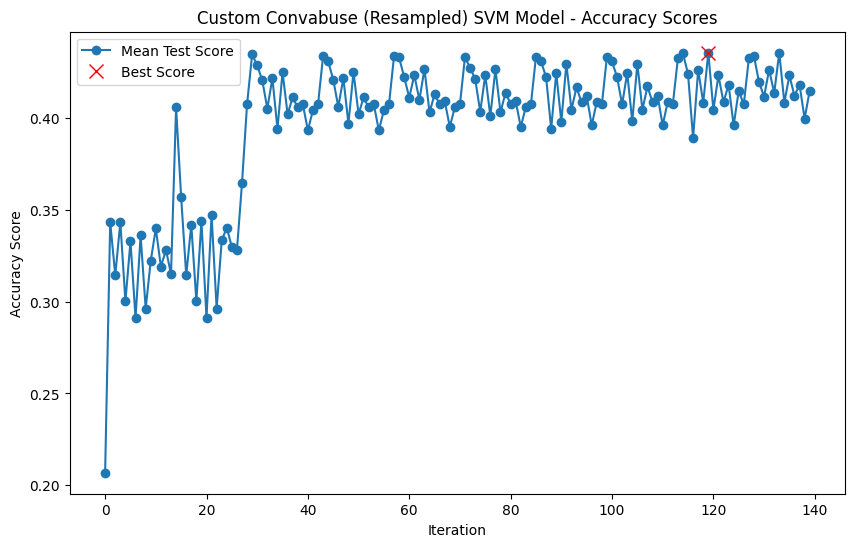

In [49]:
# Plot all accuracy scores for the custom SVM model
plt.figure(figsize=(10, 6))
plt.plot(convabuse_custom_svm_grid_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot a red x at the maximum accuracy score
best_convabuse_custom_svm_score_index = np.argmax(convabuse_custom_svm_grid_search.cv_results_['mean_test_score'])
plt.plot(best_convabuse_custom_svm_score_index, convabuse_custom_svm_grid_search.cv_results_['mean_test_score'][best_convabuse_custom_svm_score_index], 'rx', markersize=10, label='Best Score')

plt.title(f'Custom Convabuse ({balance}) SVM Model - Accuracy Scores')
plt.xlabel('Iteration')
plt.ylabel('Accuracy Score')
plt.legend()
plt.show()

In [50]:
# Print the best parameters and score from the grid search using the pickled model
print("Best parameters for SVM with linear kernel and L1 penalty:")
pprint(convabuse_custom_svm_grid_search.best_params_)
print("Best score for SVM with linear kernel and L1 penalty:")
print(convabuse_custom_svm_grid_search.best_score_)

# Get the best kernel
best_convabuse_custom_kernel = convabuse_custom_svm_grid_search.best_params_['kernel']

Best parameters for SVM with linear kernel and L1 penalty:
{'C': np.float64(0.9),
 'class_weight': 'balanced',
 'kernel': 'linear',
 'max_iter': 8}
Best score for SVM with linear kernel and L1 penalty:
0.4356510008273341


In [51]:
# Train the SVM model with the best parameters
convabuse_custom_svm_best_model = convabuse_custom_svm_grid_search.best_estimator_
convabuse_custom_svm_best_model.fit(convabuse_X_train, convabuse_y_train)

SVC(C=np.float64(0.9), class_weight='balanced', kernel='linear', max_iter=8)

In [52]:
# Use the model to make predictions on the test set
convabuse_custom_y_pred = convabuse_custom_svm_model.predict(convabuse_X_test)

# Print the classification report
print("Classification report for Convabuse dataset with L1 regularization:")
print(classification_report(convabuse_y_test, convabuse_custom_y_pred))

Classification report for Convabuse dataset with L1 regularization:
              precision    recall  f1-score   support

           0       0.37      0.40      0.39      1006
           1       0.34      0.31      0.32      1006
           2       0.84      0.42      0.56      1006
           3       0.00      0.00      0.00      1007
           4       0.40      1.00      0.57      1006

    accuracy                           0.43      5031
   macro avg       0.39      0.43      0.37      5031
weighted avg       0.39      0.43      0.37      5031



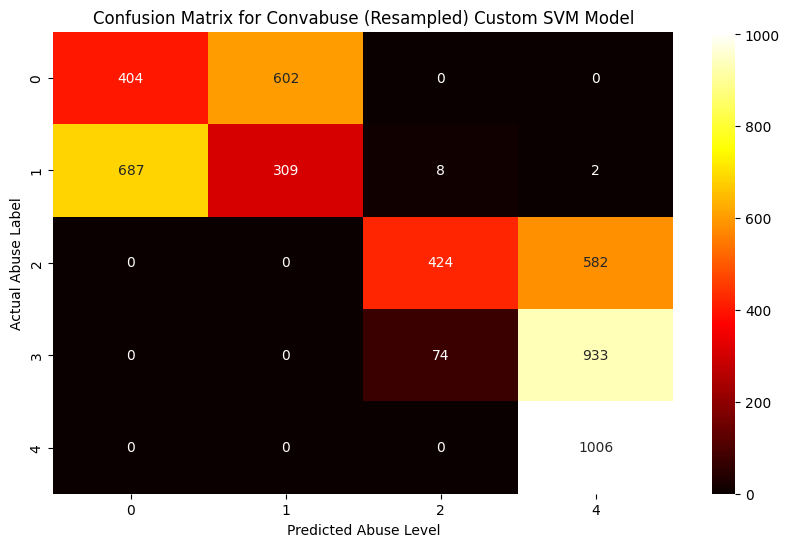

In [53]:
# Plot a heatmap of the predicted vs actual abuse levels
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(convabuse_y_test, convabuse_custom_y_pred, rownames=['Actual Abuse Label'], colnames=['Predicted Abuse Level']), annot=True, fmt='d', cmap='hot')
plt.title(f'Confusion Matrix for Convabuse ({balance}) Custom SVM Model')
plt.show()

,feature,importance_mean,importance_std
4,system,0.196979,0.004535
6,implicit,0.066925,0.004298
3,individual,0.000000,0.000000
2,generalised,0.000000,0.000000
1,bot,-0.015027,0.001491
5,explicit,-0.015941,0.002148
7,target_groups,-0.026754,0.003964
0,annotator_id,-0.046412,0.003195


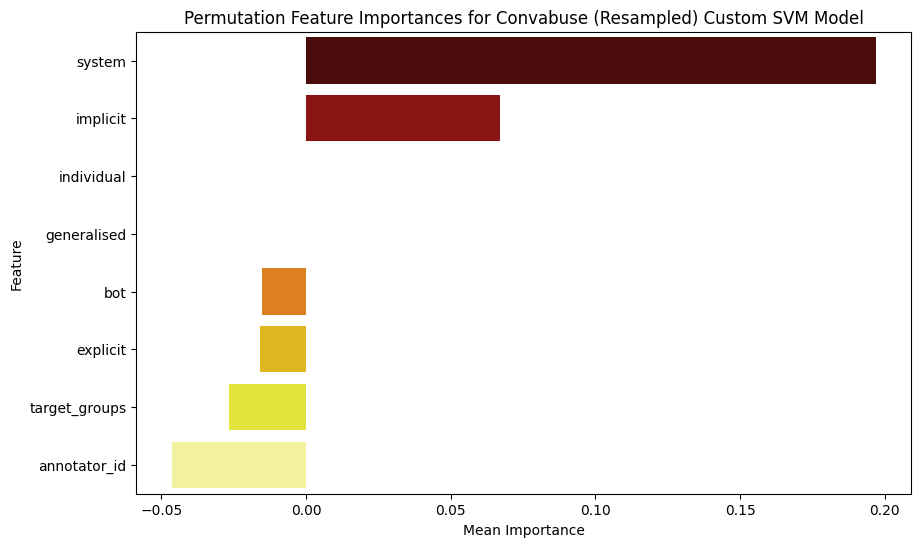

In [54]:
from sklearn.inspection import permutation_importance

# Determine the feature importances using permutation importance
perm_importance = permutation_importance(convabuse_custom_svm_best_model, convabuse_X_test, convabuse_y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Organize the results into a DataFrame
convabuse_custom_svm_model_perm_importances = pd.DataFrame({
    'feature': convabuse_X_test.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

display(convabuse_custom_svm_model_perm_importances)

# Condense into a dictionary with each feature key and importance mean value
convabuse_custom_svm_model_perm_importances_dict = convabuse_custom_svm_model_perm_importances.set_index('feature')['importance_mean'].to_dict()

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance_mean', y='feature', data=convabuse_custom_svm_model_perm_importances, palette='hot')
plt.title(f'Permutation Feature Importances for Convabuse ({balance}) Custom SVM Model')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.show()

In [55]:
# Get the custom model's accuracy and f1-score
convabuse_custom_accuracy = accuracy_score(convabuse_y_test, convabuse_custom_y_pred)
convabuse_custom_f1_score = f1_score(convabuse_y_test, convabuse_custom_y_pred, average='weighted')
print(f"Custom SVM Model Accuracy: {convabuse_custom_accuracy}")
print(f"Custom SVM Model F1-Score: {convabuse_custom_f1_score}")

Custom SVM Model Accuracy: 0.4259590538660306
Custom SVM Model F1-Score: 0.3676610685029406


In [56]:
svm_classification_results_list.append(("Convabuse", best_convabuse_custom_kernel, "L1", convabuse_custom_accuracy, convabuse_custom_f1_score, convabuse_custom_svm_model_perm_importances_dict))

In [57]:
svm_classification_results_list

[('Convabuse',
  'Linear',
  'L1',
  0.535678791492745,
  0.5138186780532034,
  {'system': 0.11788908765652953,
   'implicit': 0.10230570463128603,
   'explicit': 0.0796660703637448,
   'bot': 0.043589743589743594,
   'annotator_id': 0.01612005565493938,
   'generalised': 0.0,
   'individual': 0.0,
   'target_groups': -0.004830053667262968}),
 ('Convabuse',
  'RBF',
  'L2',
  0.5358775591333731,
  0.519119606435703,
  {'system': 0.22393162393162394,
   'explicit': 0.08547008547008547,
   'target_groups': 0.06022659511031606,
   'implicit': 0.058437686344663106,
   'annotator_id': 0.0385012919896641,
   'bot': 0.03172331544424567,
   'individual': 0.0,
   'generalised': 0.0}),
 ('Convabuse',
  'linear',
  'L1',
  0.4259590538660306,
  0.3676610685029406,
  {'system': 0.1969787318624528,
   'implicit': 0.06692506459948319,
   'individual': 0.0,
   'generalised': 0.0,
   'bot': -0.015026833631484798,
   'explicit': -0.015941164778374074,
   'target_groups': -0.02675412442854303,
   'annot

## Dynamicaly Generated Hate Speech Support Vector Machines

In [58]:
# Use grid search to find the best hyperparameters for the Linear SVC model
dghs_svm_linear_param_grid = {
    'C': np.linspace(0.1, 1, 10), # Regularization parameter
    'loss': ['squared_hinge'], # Loss function
    'max_iter': range(1, dghs_max_iter), # range(1, 8), # Maximum number of iterations
    'tol': [1e-4] # Tolerance for stopping criteria
}

In [59]:
dghs_svm_linear_grid_search = GridSearchCV(svm.LinearSVC(), dghs_svm_linear_param_grid, cv=dghs_kfold, scoring='accuracy')
dghs_svm_linear_grid_search.fit(dghs_X_train, dghs_y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LinearSVC(),
             param_grid={'C': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
                         'loss': ['squared_hinge'], 'max_iter': range(1, 15),
                         'tol': [0.0001]},
             scoring='accuracy')

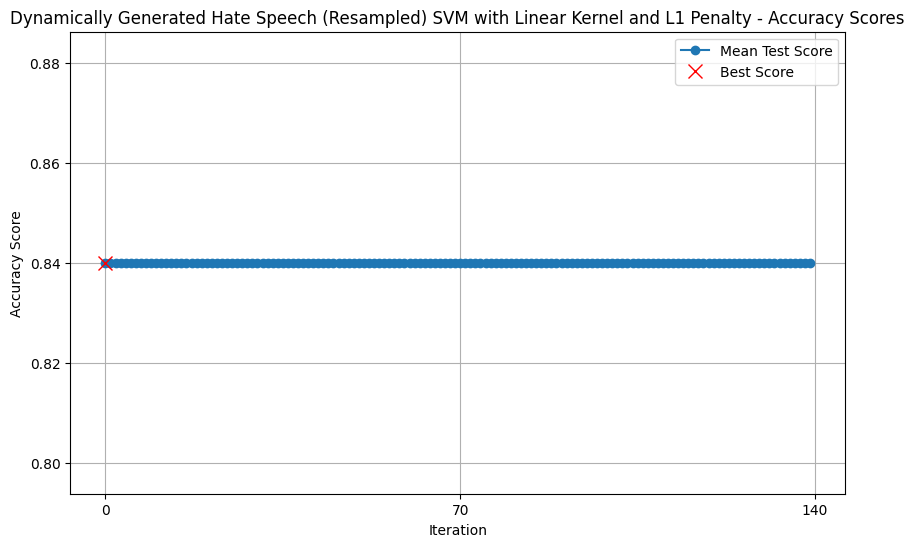

In [60]:
# Plot all accuracy scores for the SVM model with linear kernel and L1 penalty for each iteration
plt.figure(figsize=(10, 6))
plt.plot(dghs_svm_linear_grid_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot a red x at the best score
dghs_linear_best_score_index = np.argmax(dghs_svm_linear_grid_search.cv_results_['mean_test_score'])
plt.plot(dghs_linear_best_score_index, dghs_svm_linear_grid_search.cv_results_['mean_test_score'][dghs_linear_best_score_index], 'rx', markersize=10, label='Best Score')

plt.title(f'Dynamically Generated Hate Speech ({balance}) SVM with Linear Kernel and L1 Penalty - Accuracy Scores')
plt.xlabel('Iteration')
plt.ylabel('Accuracy Score')
plt.xticks([0, len(dghs_svm_linear_grid_search.cv_results_['mean_test_score']) / 2, len(dghs_svm_linear_grid_search.cv_results_['mean_test_score'])])
plt.grid()
plt.legend()
plt.show()

In [61]:
# Print the best parameters and score from the grid search using the pickled model
print("Best parameters for SVM with linear kernel and L1 penalty (from pickled model):")
pprint(dghs_svm_linear_grid_search.best_params_)
print("Best score for SVM with linear kernel and L1 penalty (from pickled model):")
print(dghs_svm_linear_grid_search.best_score_)

Best parameters for SVM with linear kernel and L1 penalty (from pickled model):
{'C': np.float64(0.1), 'loss': 'squared_hinge', 'max_iter': 1, 'tol': 0.0001}
Best score for SVM with linear kernel and L1 penalty (from pickled model):
0.8400658978583195


In [62]:
# Train the SVM model with the best parameters
dghs_svm_model_linear = svm.LinearSVC(**dghs_svm_linear_grid_search.best_params_, random_state=42)
dghs_svm_model_linear.fit(dghs_X_train, dghs_y_train)

LinearSVC(C=np.float64(0.1), max_iter=1, random_state=42)

In [63]:
# Print the classification report for the dghs_svm_model_linear model
dghs_y_pred_linear = dghs_svm_model_linear.predict(dghs_X_test)
print("Classification report for SVM with linear kernel and L1 penalty:")
print(classification_report(dghs_y_test, dghs_y_pred_linear))
print(f"F1 Score: {f1_score(dghs_y_test, dghs_y_pred_linear, average='weighted'):.4f}")
print(f"Accuracy: {accuracy_score(dghs_y_test, dghs_y_pred_linear):.4f}")

Classification report for SVM with linear kernel and L1 penalty:
              precision    recall  f1-score   support

         0.0       0.75      1.00      0.86      3794
         1.0       1.00      0.67      0.81      3794

    accuracy                           0.84      7588
   macro avg       0.88      0.84      0.83      7588
weighted avg       0.88      0.84      0.83      7588

F1 Score: 0.8324
Accuracy: 0.8368


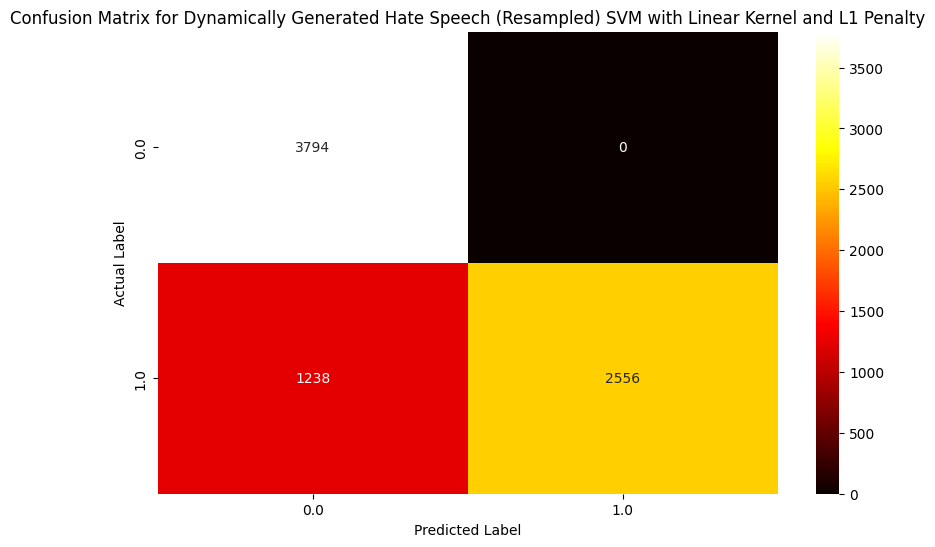

In [64]:
# Plot a heatmap of the actual vs predicted label for the us_accidents_svm_model_linear model
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(dghs_y_test, dghs_y_pred_linear, rownames=['Actual'], colnames=['Predicted']), annot=True, fmt='d', cmap='hot')
plt.title(f'Confusion Matrix for Dynamically Generated Hate Speech ({balance}) SVM with Linear Kernel and L1 Penalty')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

,feature,importance_mean,importance_std
0,type,0.335108,0.005121
1,annotator,0.000000,0.000000
2,target_groups,0.000000,0.000000
3,original,0.000000,0.000000


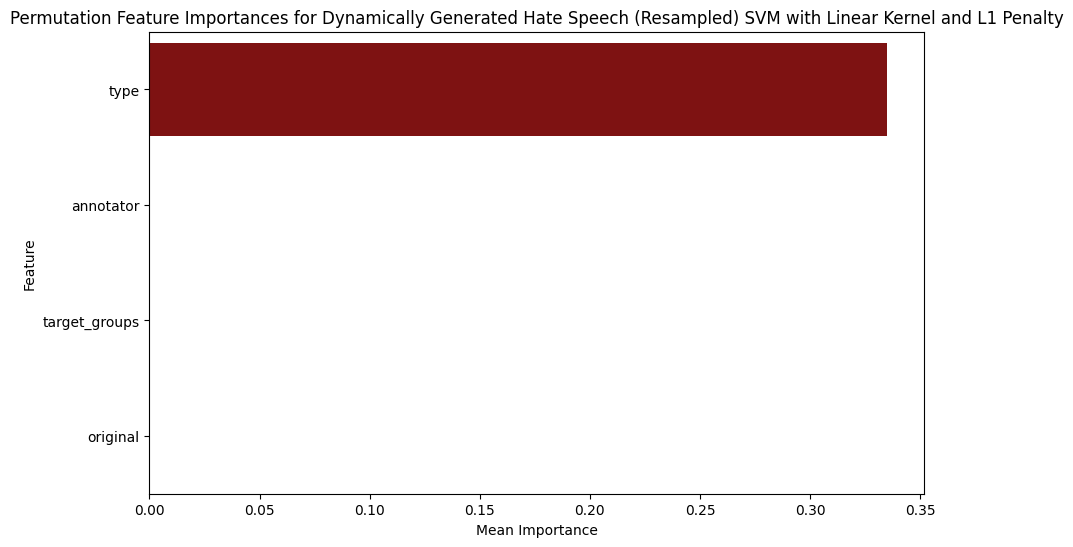

In [65]:
from sklearn.inspection import permutation_importance

# Determine the feature importances
perm_importance = permutation_importance(dghs_svm_model_linear, dghs_X_test, dghs_y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Organize the results into a DataFrame
dghs_svm_model_linear_perm_importances = pd.DataFrame({
    'feature': dghs_X_test.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)
display(dghs_svm_model_linear_perm_importances)

# Condense into a dictionary with each feature key and importance mean value
dghs_svm_model_linear_perm_importances_dict = dghs_svm_model_linear_perm_importances.set_index('feature')['importance_mean'].to_dict()

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance_mean', y='feature', data=dghs_svm_model_linear_perm_importances, palette='hot')
plt.title(f'Permutation Feature Importances for Dynamically Generated Hate Speech ({balance}) SVM with Linear Kernel and L1 Penalty')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.show()

In [66]:
svm_classification_results_list.append(("Dynamically Generated Hate Speech", "Linear", "L1", accuracy_score(dghs_y_test, dghs_y_pred_linear), f1_score(dghs_y_test, dghs_y_pred_linear, average='weighted'), dghs_svm_model_linear_perm_importances_dict))

In [67]:
dghs_svm_rbf_pipeline = Pipeline([
    ("kernel", RBFSampler()),
    ("clf", SGDClassifier(loss="hinge", random_state=42, penalty="l2", tol=1e-4))
])

In [68]:
# Use grid search to find the best hyperparameters for the SVM model
dghs_svm_rbf_param_grid = {
    'kernel__gamma': np.linspace(0.1, 1, 10), # Kernel coefficient,
    'kernel__n_components': range(2, dghs_X_train.shape[1] + 1), # Number of components for the RBF kernel
    'clf__alpha': [1e-4], # Regularization parameter
    'clf__max_iter': range(1, dghs_max_iter), # range(300, 350), # Maximum number of iterations
    'clf__tol': [1e-4], # Tolerance for stopping criteria
    'clf__early_stopping': [True] # Whether to use early stopping
}

In [69]:
# Perform a grid search using the RBFSampler
dghs_svm_rbf_grid_search = GridSearchCV(
    estimator=dghs_svm_rbf_pipeline,
    param_grid=
    dghs_svm_rbf_param_grid,
    cv=dghs_kfold,
    scoring='accuracy',
    n_jobs=2,
    verbose=True
)

In [70]:
# Fit the grid search to the training data
dghs_svm_rbf_grid_search.fit(dghs_X_train, dghs_y_train)

Fitting 5 folds for each of 420 candidates, totalling 2100 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('kernel', RBFSampler()),
                                       ('clf',
                                        SGDClassifier(random_state=42,
                                                      tol=0.0001))]),
             n_jobs=2,
             param_grid={'clf__alpha': [0.0001], 'clf__early_stopping': [True],
                         'clf__max_iter': range(1, 15), 'clf__tol': [0.0001],
                         'kernel__gamma': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
                         'kernel__n_components': range(2, 5)},
             scoring='accuracy', verbose=True)

In [71]:
# Print the best parameters and score from the grid search using the pickled model
print("Best parameters for SVM with RBF kernel (from pickled model):")
pprint(dghs_svm_rbf_grid_search.best_params_)
print("Best score for SVM with RBF kernel (from pickled model):")
print(dghs_svm_rbf_grid_search.best_score_)

Best parameters for SVM with RBF kernel (from pickled model):
{'clf__alpha': 0.0001,
 'clf__early_stopping': True,
 'clf__max_iter': 11,
 'clf__tol': 0.0001,
 'kernel__gamma': np.float64(0.1),
 'kernel__n_components': 4}
Best score for SVM with RBF kernel (from pickled model):
0.8312685337726524


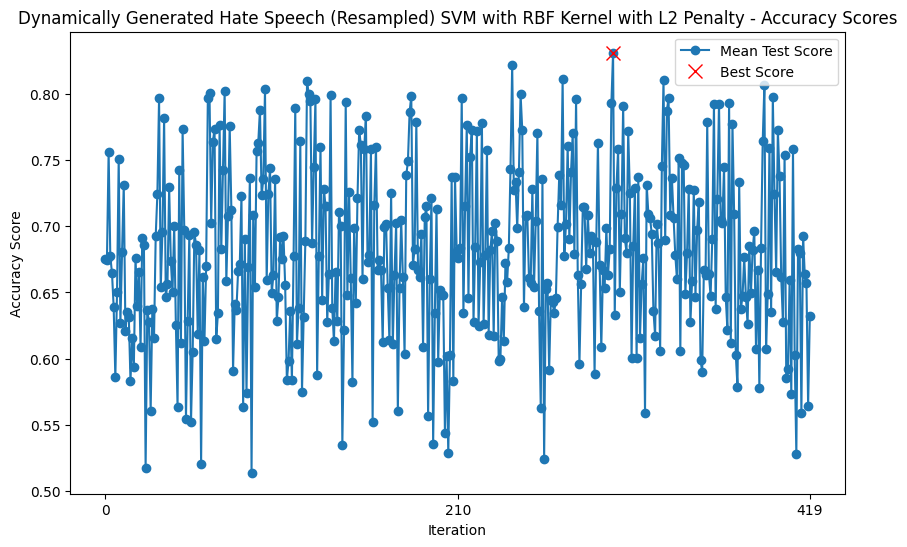

In [72]:
# Plot all accuracy scores for the SVM model with RBF kernel for each iteration
plt.figure(figsize=(10, 6))
plt.plot(dghs_svm_rbf_grid_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot a red x at the best score
best_dghs_svm_rbf_score_index = np.argmax(dghs_svm_rbf_grid_search.cv_results_['mean_test_score'])
plt.plot(best_dghs_svm_rbf_score_index, dghs_svm_rbf_grid_search.cv_results_['mean_test_score'][best_dghs_svm_rbf_score_index], 'rx', markersize=10, label='Best Score')

plt.title(f'Dynamically Generated Hate Speech ({balance}) SVM with RBF Kernel with L2 Penalty - Accuracy Scores')
plt.xlabel('Iteration')
plt.ylabel('Accuracy Score')

# Only plot x-axis ticks of 0, the median, and the last iteration
plt.xticks([0, len(dghs_svm_rbf_grid_search.cv_results_['mean_test_score']) // 2, len(dghs_svm_rbf_grid_search.cv_results_['mean_test_score']) - 1])

plt.legend()
plt.show()

In [73]:
# Train the SVM model with the best parameters
dghs_svm_model_rbf = dghs_svm_rbf_grid_search.best_estimator_
dghs_svm_model_rbf.fit(dghs_X_train, dghs_y_train)

Pipeline(steps=[('kernel', RBFSampler(gamma=np.float64(0.1), n_components=4)),
                ('clf',
                 SGDClassifier(early_stopping=True, max_iter=11,
                               random_state=42, tol=0.0001))])

In [74]:
# Print the classification report for the dghs_svm_model_rbf model
dghs_y_pred_rbf = dghs_svm_model_rbf.predict(dghs_X_test)
print("Classification report for SVM with RBF kernel:")
print(classification_report(dghs_y_test, dghs_y_pred_rbf))
print(f"F1 Score: {f1_score(dghs_y_test, dghs_y_pred_rbf, average='weighted'):.4f}")
print(f"Accuracy: {accuracy_score(dghs_y_test, dghs_y_pred_rbf):.4f}")

Classification report for SVM with RBF kernel:
              precision    recall  f1-score   support

         0.0       0.79      0.65      0.71      3794
         1.0       0.70      0.82      0.76      3794

    accuracy                           0.74      7588
   macro avg       0.75      0.74      0.74      7588
weighted avg       0.75      0.74      0.74      7588

F1 Score: 0.7367
Accuracy: 0.7385


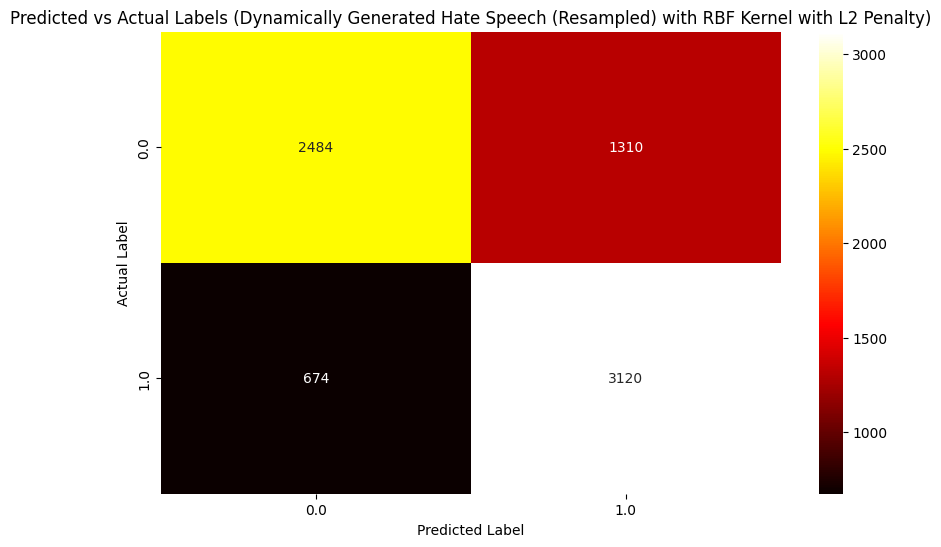

In [75]:
# Plot a heatmap of the predicted vs actual labels
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(dghs_y_test, dghs_y_pred_rbf), annot=True, fmt='d', cmap='hot')
plt.title(f'Predicted vs Actual Labels (Dynamically Generated Hate Speech ({balance}) with RBF Kernel with L2 Penalty)')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

,feature,importance_mean,importance_std
0,type,0.183026,0.003510
2,target_groups,0.025580,0.003216
1,annotator,0.014800,0.005523
3,original,0.004323,0.001422


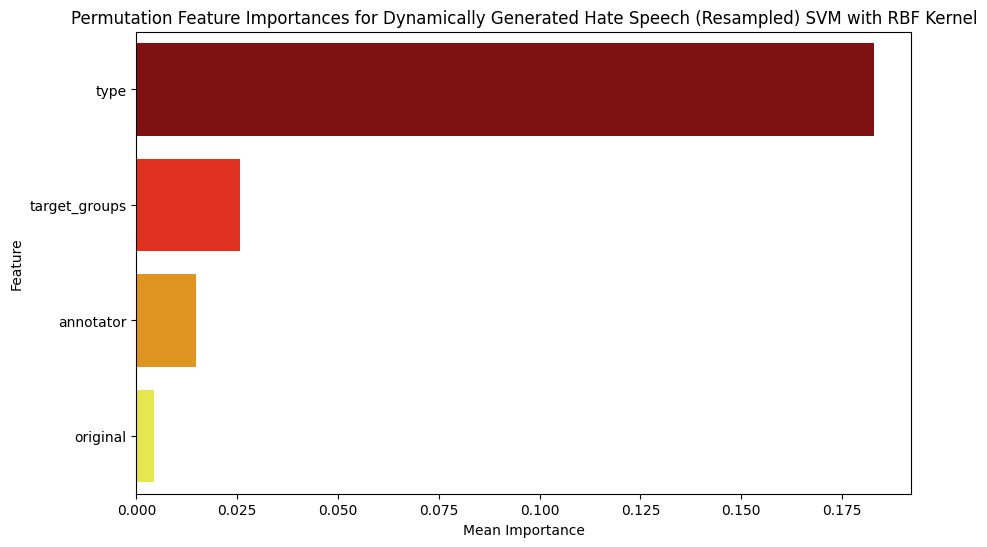

In [76]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance for the RBF kernel SVM model
perm_importance = permutation_importance(dghs_svm_model_rbf, dghs_X_test, dghs_y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Organize the results into a DataFrame
dghs_svm_rbf_perm_importance = pd.DataFrame({
    'feature': dghs_X_test.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

display(dghs_svm_rbf_perm_importance)

# Condense into a dictionary with each feature key and importance mean value
dghs_svm_rbf_perm_importances_dict = dghs_svm_rbf_perm_importance.set_index('feature')['importance_mean'].to_dict()

# Plot the permutation importance
plt.figure(figsize=(10, 6))
sns.barplot(x='importance_mean', y='feature', data=dghs_svm_rbf_perm_importance, palette='hot')
plt.title(f'Permutation Feature Importances for Dynamically Generated Hate Speech ({balance}) SVM with RBF Kernel')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.show()

In [77]:
svm_classification_results_list.append(("Dynamically Generated Hate Speech", "RBF", "L2", accuracy_score(dghs_y_test, dghs_y_pred_rbf), f1_score(dghs_y_test, dghs_y_pred_rbf, average='weighted'), dghs_svm_rbf_perm_importances_dict))

In [78]:
dghs_custom_param_grid = {
    "C": np.linspace(0.1, 1, 10),
    "kernel": ["linear", "poly", "rbf"],
    "max_iter": range(1, dghs_max_iter), # range(100, 1000, 100),
    "class_weight": [None]
}

In [79]:
# Train and evaluate the SVM model on the US Accidents Upsampled dataset
dghs_custom_svm_grid_search, dghs_custom_svm_model = svm_grid_search(dghs_X_train, dghs_X_test, dghs_y_train, dghs_y_test, dghs_custom_param_grid, dghs_kfold, "dghs_custom_svm_model")

Fitting 5 folds for each of 420 candidates, totalling 2100 fits
Parameters tested for dghs_custom_svm_model:
[{'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 1},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 2},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 3},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 4},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 5},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 6},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 7},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 8},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 9},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 10},
 {'C': np.

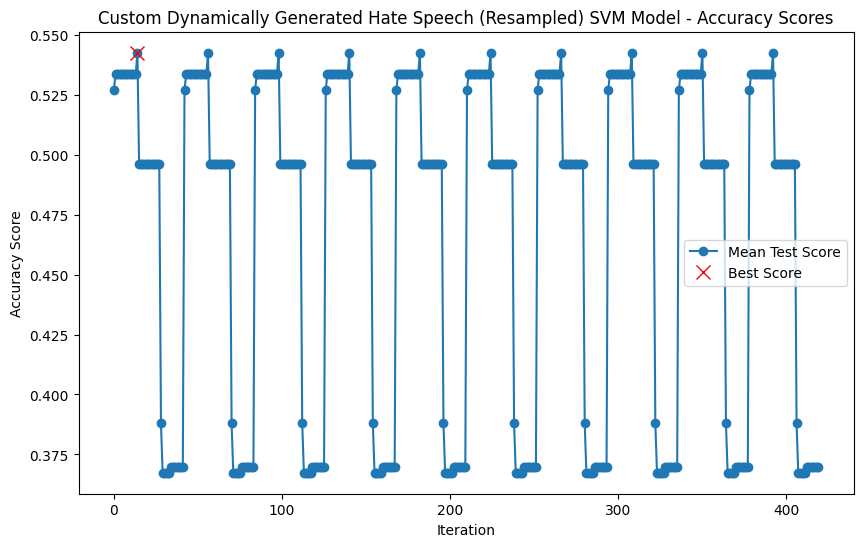

In [80]:
# Plot all accuracy scores for the custom SVM model
plt.figure(figsize=(10, 6))
plt.plot(dghs_custom_svm_grid_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot a red x at the maximum accuracy score
best_dghs_custom_svm_score_index = np.argmax(dghs_custom_svm_grid_search.cv_results_['mean_test_score'])
plt.plot(best_dghs_custom_svm_score_index, dghs_custom_svm_grid_search.cv_results_['mean_test_score'][best_dghs_custom_svm_score_index], 'rx', markersize=10, label='Best Score')

plt.title(f'Custom Dynamically Generated Hate Speech ({balance}) SVM Model - Accuracy Scores')
plt.xlabel('Iteration')
plt.ylabel('Accuracy Score')
plt.legend()
plt.show()

In [81]:
# Print the best parameters and score from the grid search using the pickled model
print("Best parameters for SVM with linear kernel and L1 penalty (from pickled model):")
pprint(dghs_custom_svm_grid_search.best_params_)
print("Best score for SVM with linear kernel and L1 penalty (from pickled model):")
print(dghs_custom_svm_grid_search.best_score_)

# Get the best kernel
best_dghs_custom_kernel = dghs_custom_svm_grid_search.best_params_['kernel']
print(f"Best kernel: {best_dghs_custom_kernel}")

Best parameters for SVM with linear kernel and L1 penalty (from pickled model):
{'C': np.float64(0.1), 'class_weight': None, 'kernel': 'poly', 'max_iter': 1}
Best score for SVM with linear kernel and L1 penalty (from pickled model):
0.5424711696869852
Best kernel: poly


In [82]:
# Train the SVM model with the best parameters
dghs_custom_svm_best_model = dghs_custom_svm_grid_search.best_estimator_
dghs_custom_svm_best_model.fit(dghs_X_train, dghs_y_train)

SVC(C=np.float64(0.1), kernel='poly', max_iter=1)

In [83]:
# Use the model to make predictions on the test set
dghs_custom_y_pred = dghs_custom_svm_model.predict(dghs_X_test)

# Print the classification report
print("Classification report for US Accidents Upsampled dataset with L1 regularization:")
print(classification_report(dghs_y_test, dghs_custom_y_pred))

Classification report for US Accidents Upsampled dataset with L1 regularization:
              precision    recall  f1-score   support

         0.0       0.58      0.33      0.42      3794
         1.0       0.53      0.77      0.63      3794

    accuracy                           0.55      7588
   macro avg       0.56      0.55      0.52      7588
weighted avg       0.56      0.55      0.52      7588



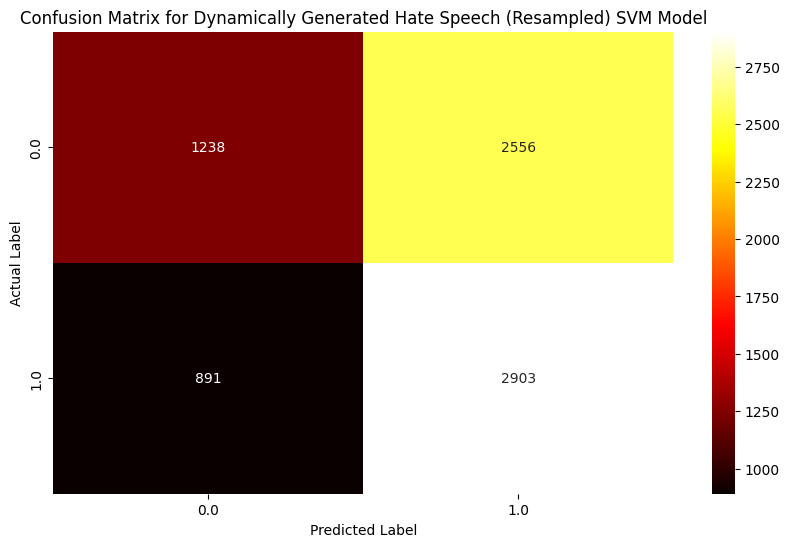

In [84]:
# Plot a heatmap of the predicted vs actual labels
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(dghs_y_test, dghs_custom_y_pred, rownames=['Actual Label'], colnames=['Predicted Label']), annot=True, fmt='d', cmap='hot')
plt.title(f'Confusion Matrix for Dynamically Generated Hate Speech ({balance}) SVM Model')
plt.show()

,feature,importance_mean,importance_std
3,original,0.029468,0.005124
0,type,0.004797,0.002753
1,annotator,0.001120,0.001791
2,target_groups,-0.041724,0.001673


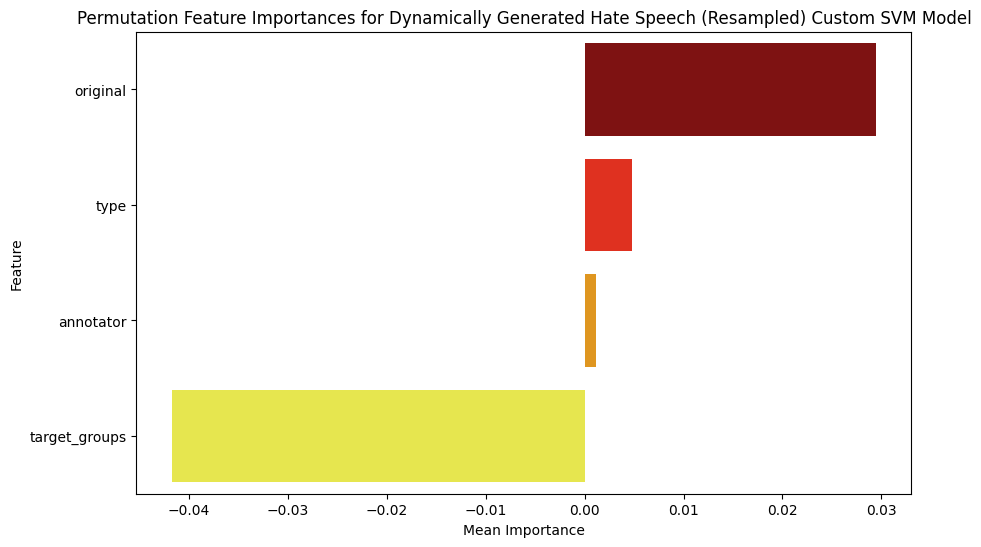

In [85]:
from sklearn.inspection import permutation_importance

# Determine the feature importances using permutation importance
perm_importance = permutation_importance(dghs_custom_svm_best_model, dghs_X_test, dghs_y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Organize the results into a DataFrame
dghs_custom_svm_model_perm_importances = pd.DataFrame({
    'feature': dghs_X_test.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

display(dghs_custom_svm_model_perm_importances)

# Condense into a dictionary with each feature key and importance mean value
dghs_custom_svm_model_perm_importances_dict = dghs_custom_svm_model_perm_importances.set_index('feature')['importance_mean'].to_dict()

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance_mean', y='feature', data=dghs_custom_svm_model_perm_importances, palette='hot')
plt.title(f'Permutation Feature Importances for Dynamically Generated Hate Speech ({balance}) Custom SVM Model')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.show()

In [86]:
# Get the custom model's accuracy and f1-score
dghs_custom_accuracy = accuracy_score(dghs_y_test, dghs_custom_y_pred)
dghs_custom_f1_score = f1_score(dghs_y_test, dghs_custom_y_pred, average='weighted')
print(f"Custom SVM Model Accuracy: {dghs_custom_accuracy}")
print(f"Custom SVM Model F1-Score: {dghs_custom_f1_score}")

Custom SVM Model Accuracy: 0.5457301001581445
Custom SVM Model F1-Score: 0.5227517870964783


In [87]:
svm_classification_results_list.append(("Dynamically Generated Hate Speech", best_dghs_custom_kernel, "L1", dghs_custom_accuracy, dghs_custom_f1_score, dghs_custom_svm_model_perm_importances_dict))

In [88]:
svm_classification_results_list

[('Convabuse',
  'Linear',
  'L1',
  0.535678791492745,
  0.5138186780532034,
  {'system': 0.11788908765652953,
   'implicit': 0.10230570463128603,
   'explicit': 0.0796660703637448,
   'bot': 0.043589743589743594,
   'annotator_id': 0.01612005565493938,
   'generalised': 0.0,
   'individual': 0.0,
   'target_groups': -0.004830053667262968}),
 ('Convabuse',
  'RBF',
  'L2',
  0.5358775591333731,
  0.519119606435703,
  {'system': 0.22393162393162394,
   'explicit': 0.08547008547008547,
   'target_groups': 0.06022659511031606,
   'implicit': 0.058437686344663106,
   'annotator_id': 0.0385012919896641,
   'bot': 0.03172331544424567,
   'individual': 0.0,
   'generalised': 0.0}),
 ('Convabuse',
  'linear',
  'L1',
  0.4259590538660306,
  0.3676610685029406,
  {'system': 0.1969787318624528,
   'implicit': 0.06692506459948319,
   'individual': 0.0,
   'generalised': 0.0,
   'bot': -0.015026833631484798,
   'explicit': -0.015941164778374074,
   'target_groups': -0.02675412442854303,
   'annot

## Online Abusive Attacks Support Vector Machines

In [89]:
# Use grid search to find the best hyperparameters for the Linear SVC model
oaa_svm_linear_param_grid = {
    'C': np.linspace(0.1, 1, 10), # Regularization parameter
    'loss': ['squared_hinge'], # Loss function
    'max_iter': range(1, oaa_max_iter), # range(1, 8), # Maximum number of iterations
    'tol': [1e-4] # Tolerance for stopping criteria
}

In [90]:
oaa_svm_linear_grid_search = GridSearchCV(svm.LinearSVC(), oaa_svm_linear_param_grid, cv=oaa_kfold, scoring='accuracy')
oaa_svm_linear_grid_search.fit(oaa_X_train, oaa_y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LinearSVC(),
             param_grid={'C': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
                         'loss': ['squared_hinge'], 'max_iter': range(1, 13),
                         'tol': [0.0001]},
             scoring='accuracy')

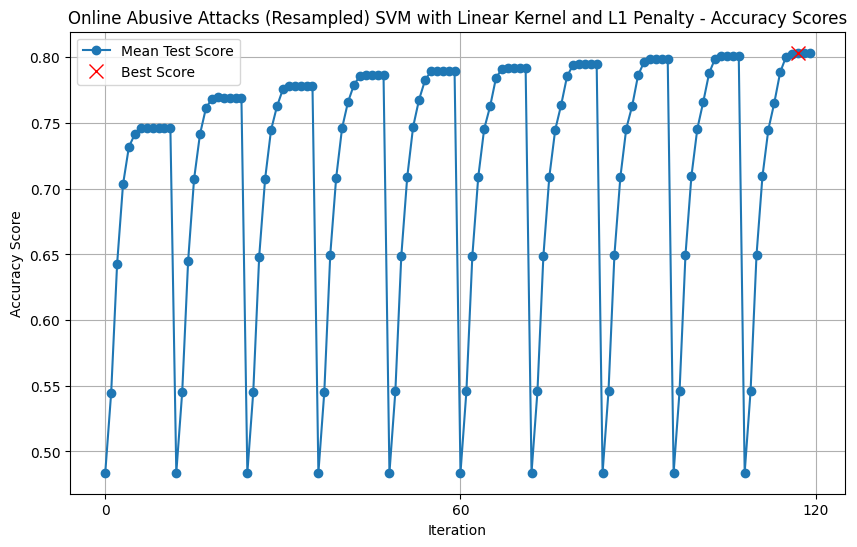

In [91]:
# Plot all accuracy scores for the SVM model with linear kernel and L1 penalty for each iteration
plt.figure(figsize=(10, 6))
plt.plot(oaa_svm_linear_grid_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot a red x at the best score
oaa_linear_best_score_index = np.argmax(oaa_svm_linear_grid_search.cv_results_['mean_test_score'])
plt.plot(oaa_linear_best_score_index, oaa_svm_linear_grid_search.cv_results_['mean_test_score'][oaa_linear_best_score_index], 'rx', markersize=10, label='Best Score')

plt.title(f'Online Abusive Attacks ({balance}) SVM with Linear Kernel and L1 Penalty - Accuracy Scores')
plt.xlabel('Iteration')
plt.ylabel('Accuracy Score')
plt.xticks([0, len(oaa_svm_linear_grid_search.cv_results_['mean_test_score']) / 2, len(oaa_svm_linear_grid_search.cv_results_['mean_test_score'])])
plt.grid()
plt.legend()
plt.show()

In [92]:
# Print the best parameters and score from the grid search
print("Best parameters for SVM with linear kernel and L1 penalty:")
pprint(oaa_svm_linear_grid_search.best_params_)
print("Best score for SVM with linear kernel and L1 penalty:")
print(oaa_svm_linear_grid_search.best_score_)

Best parameters for SVM with linear kernel and L1 penalty:
{'C': np.float64(1.0), 'loss': 'squared_hinge', 'max_iter': 10, 'tol': 0.0001}
Best score for SVM with linear kernel and L1 penalty:
0.803511330746578


In [93]:
# Train the SVM model with the best parameters
oaa_svm_model_linear = svm.LinearSVC(**oaa_svm_linear_grid_search.best_params_, random_state=42)
oaa_svm_model_linear.fit(oaa_X_train, oaa_y_train)

LinearSVC(C=np.float64(1.0), max_iter=10, random_state=42)

In [94]:
# Print the classification report for the oaa_svm_model_linear model
oaa_y_pred_linear = oaa_svm_model_linear.predict(oaa_X_test)
print("Classification report for SVM with linear kernel and L1 penalty:")
print(classification_report(oaa_y_test, oaa_y_pred_linear))
print(f"F1 Score: {f1_score(oaa_y_test, oaa_y_pred_linear, average='weighted'):.4f}")
print(f"Accuracy: {accuracy_score(oaa_y_test, oaa_y_pred_linear):.4f}")

Classification report for SVM with linear kernel and L1 penalty:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86       242
           1       0.72      0.55      0.62       215
           2       0.70      0.64      0.67       199
           3       0.88      0.79      0.83       227
           4       0.96      1.00      0.98       229

    accuracy                           0.81      1112
   macro avg       0.80      0.80      0.79      1112
weighted avg       0.80      0.81      0.80      1112

F1 Score: 0.7991
Accuracy: 0.8067


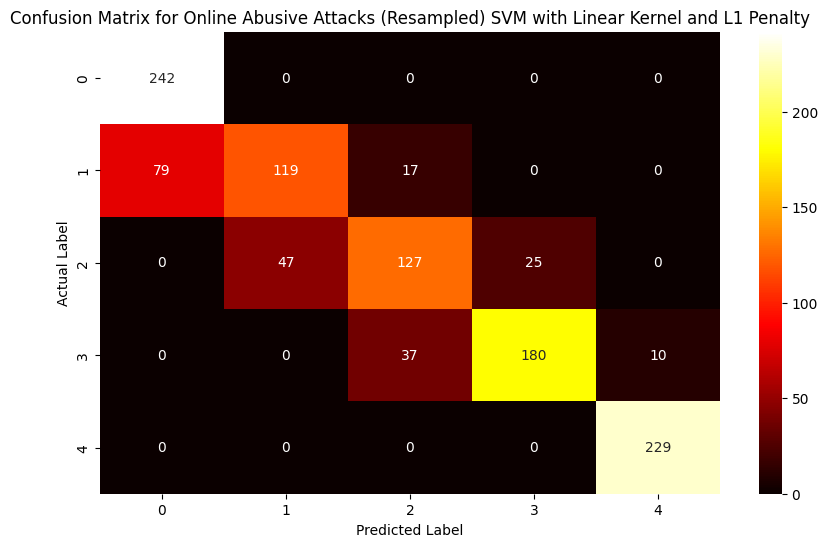

In [95]:
# Plot a heatmap of the actual vs predicted label for the us_accidents_svm_model_linear model
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(oaa_y_test, oaa_y_pred_linear, rownames=['Actual'], colnames=['Predicted']), annot=True, fmt='d', cmap='hot')
plt.title(f'Confusion Matrix for Online Abusive Attacks ({balance}) SVM with Linear Kernel and L1 Penalty')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

,feature,importance_mean,importance_std
1,Toxic parent tweets,0.552068,0.013992
2,Toxic replies,0.157464,0.008383
0,index,-0.027248,0.009355


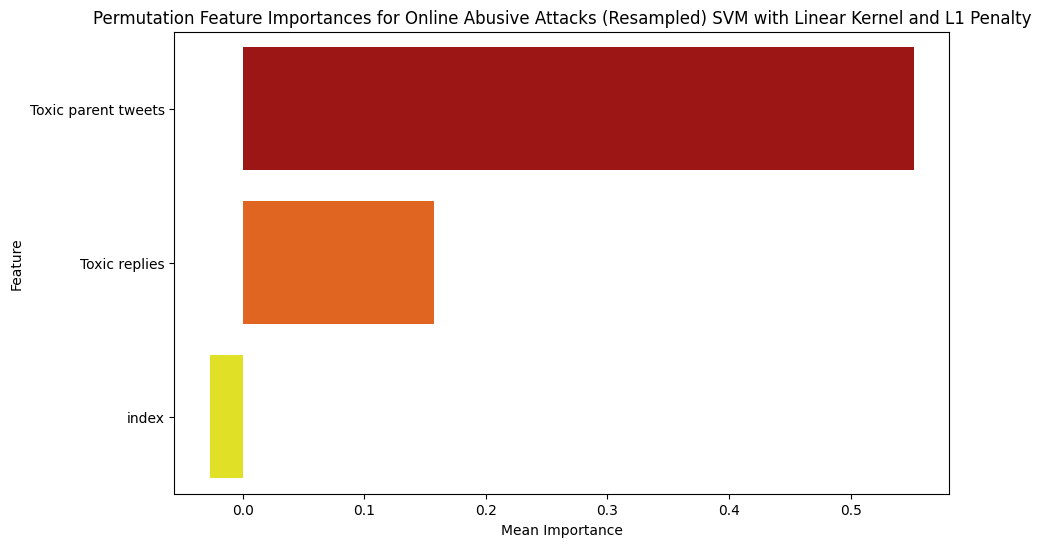

In [96]:
from sklearn.inspection import permutation_importance

# Determine the feature importances
perm_importance = permutation_importance(oaa_svm_model_linear, oaa_X_test, oaa_y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Organize the results into a DataFrame
oaa_svm_model_linear_perm_importances = pd.DataFrame({
    'feature': oaa_X_test.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)
display(oaa_svm_model_linear_perm_importances)

# Condense into a dictionary with each feature key and importance mean value
oaa_svm_model_linear_perm_importances_dict = oaa_svm_model_linear_perm_importances.set_index('feature')['importance_mean'].to_dict()

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance_mean', y='feature', data=oaa_svm_model_linear_perm_importances, palette='hot')
plt.title(f'Permutation Feature Importances for Online Abusive Attacks ({balance}) SVM with Linear Kernel and L1 Penalty')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.show()

In [97]:
svm_classification_results_list.append(("Online Abusive Attacks", "Linear", "L1", accuracy_score(dghs_y_test, dghs_y_pred_linear), f1_score(dghs_y_test, dghs_y_pred_linear, average='weighted'), dghs_svm_model_linear_perm_importances_dict))

In [98]:
oaa_svm_rbf_pipeline = Pipeline([
    ("kernel", RBFSampler()),
    ("clf", SGDClassifier(loss="hinge", random_state=42, penalty="l2", tol=1e-4))
])

In [99]:
# Use grid search to find the best hyperparameters for the SVM model
oaa_svm_rbf_param_grid = {
    'kernel__gamma': np.linspace(0.1, 1, 10), # Kernel coefficient,
    'kernel__n_components': range(2, oaa_X_train.shape[1] + 1), # Number of components for the RBF kernel
    'clf__alpha': [1e-4], # Regularization parameter
    'clf__max_iter': range(1, oaa_max_iter), # range(300, 350), # Maximum number of iterations
    'clf__tol': [1e-4], # Tolerance for stopping criteria
    'clf__early_stopping': [True] # Whether to use early stopping
}

In [100]:
# Perform a grid search using the RBFSampler
oaa_svm_rbf_grid_search = GridSearchCV(
    estimator=oaa_svm_rbf_pipeline,
    param_grid=
    oaa_svm_rbf_param_grid,
    cv=oaa_kfold,
    scoring='accuracy',
    n_jobs=2,
    verbose=True
)

In [101]:
# Fit the grid search to the training data
oaa_svm_rbf_grid_search.fit(oaa_X_train, oaa_y_train)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('kernel', RBFSampler()),
                                       ('clf',
                                        SGDClassifier(random_state=42,
                                                      tol=0.0001))]),
             n_jobs=2,
             param_grid={'clf__alpha': [0.0001], 'clf__early_stopping': [True],
                         'clf__max_iter': range(1, 13), 'clf__tol': [0.0001],
                         'kernel__gamma': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
                         'kernel__n_components': range(2, 4)},
             scoring='accuracy', verbose=True)

In [102]:
# Print the best parameters and score from the grid search using the pickled model
print("Best parameters for SVM with RBF kernel (from pickled model):")
pprint(oaa_svm_rbf_grid_search.best_params_)
print("Best score for SVM with RBF kernel (from pickled model):")
print(oaa_svm_rbf_grid_search.best_score_)

Best parameters for SVM with RBF kernel (from pickled model):
{'clf__alpha': 0.0001,
 'clf__early_stopping': True,
 'clf__max_iter': 11,
 'clf__tol': 0.0001,
 'kernel__gamma': np.float64(0.30000000000000004),
 'kernel__n_components': 3}
Best score for SVM with RBF kernel (from pickled model):
0.560039433273088


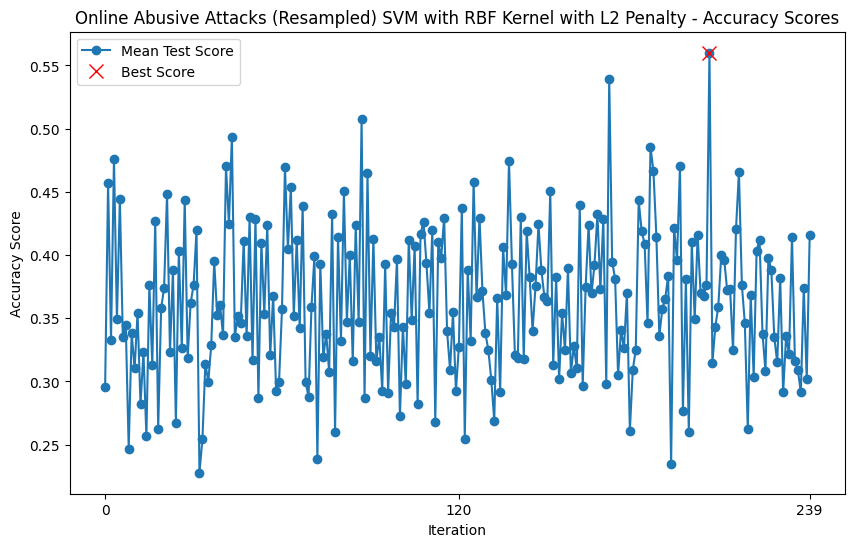

In [103]:
# Plot all accuracy scores for the SVM model with RBF kernel for each iteration
plt.figure(figsize=(10, 6))
plt.plot(oaa_svm_rbf_grid_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot a red x at the best score
best_oaa_svm_rbf_score_index = np.argmax(oaa_svm_rbf_grid_search.cv_results_['mean_test_score'])
plt.plot(best_oaa_svm_rbf_score_index, oaa_svm_rbf_grid_search.cv_results_['mean_test_score'][best_oaa_svm_rbf_score_index], 'rx', markersize=10, label='Best Score')

plt.title(f'Online Abusive Attacks ({balance}) SVM with RBF Kernel with L2 Penalty - Accuracy Scores')
plt.xlabel('Iteration')
plt.ylabel('Accuracy Score')

# Only plot x-axis ticks of 0, the median, and the last iteration
plt.xticks([0, len(oaa_svm_rbf_grid_search.cv_results_['mean_test_score']) // 2, len(oaa_svm_rbf_grid_search.cv_results_['mean_test_score']) - 1])

plt.legend()
plt.show()

In [104]:
# Train the SVM model with the best parameters
oaa_svm_model_rbf = oaa_svm_rbf_grid_search.best_estimator_
oaa_svm_model_rbf.fit(oaa_X_train, oaa_y_train)

Pipeline(steps=[('kernel',
                 RBFSampler(gamma=np.float64(0.30000000000000004),
                            n_components=3)),
                ('clf',
                 SGDClassifier(early_stopping=True, max_iter=11,
                               random_state=42, tol=0.0001))])

In [105]:
# Print the classification report for the oaa_svm_model_rbf model
oaa_y_pred_rbf = oaa_svm_model_rbf.predict(oaa_X_test)
print("Classification report for SVM with RBF kernel:")
print(classification_report(oaa_y_test, oaa_y_pred_rbf))
print(f"F1 Score: {f1_score(oaa_y_test, oaa_y_pred_rbf, average='weighted'):.4f}")
print(f"Accuracy: {accuracy_score(oaa_y_test, oaa_y_pred_rbf):.4f}")

Classification report for SVM with RBF kernel:
              precision    recall  f1-score   support

           0       0.71      0.79      0.75       242
           1       0.00      0.00      0.00       215
           2       0.36      0.59      0.45       199
           3       0.39      0.20      0.27       227
           4       0.44      0.77      0.56       229

    accuracy                           0.48      1112
   macro avg       0.38      0.47      0.40      1112
weighted avg       0.39      0.48      0.41      1112

F1 Score: 0.4126
Accuracy: 0.4775


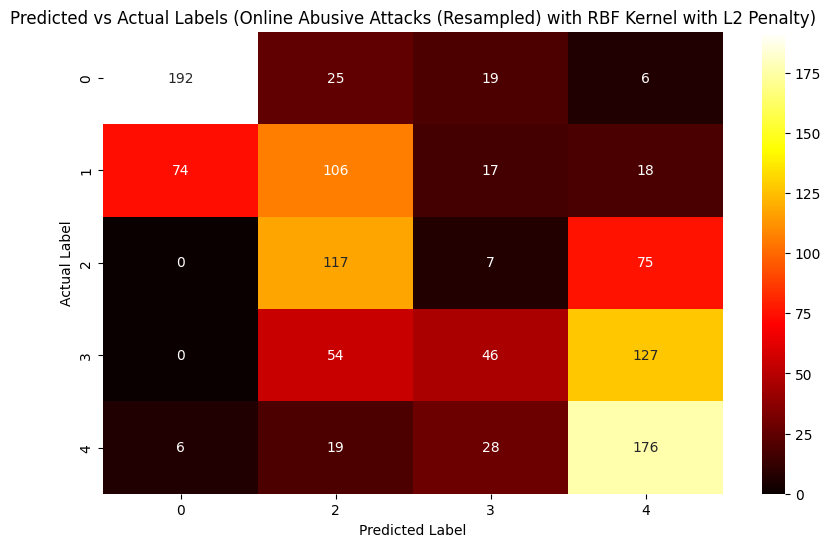

In [106]:
# Plot a heatmap of the predicted vs actual labels
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(oaa_y_test, oaa_y_pred_rbf), annot=True, fmt='d', cmap='hot')
plt.title(f'Predicted vs Actual Labels (Online Abusive Attacks ({balance}) with RBF Kernel with L2 Penalty)')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

,feature,importance_mean,importance_std
1,Toxic parent tweets,0.220144,0.007326
2,Toxic replies,0.096673,0.008486
0,index,0.039029,0.007675


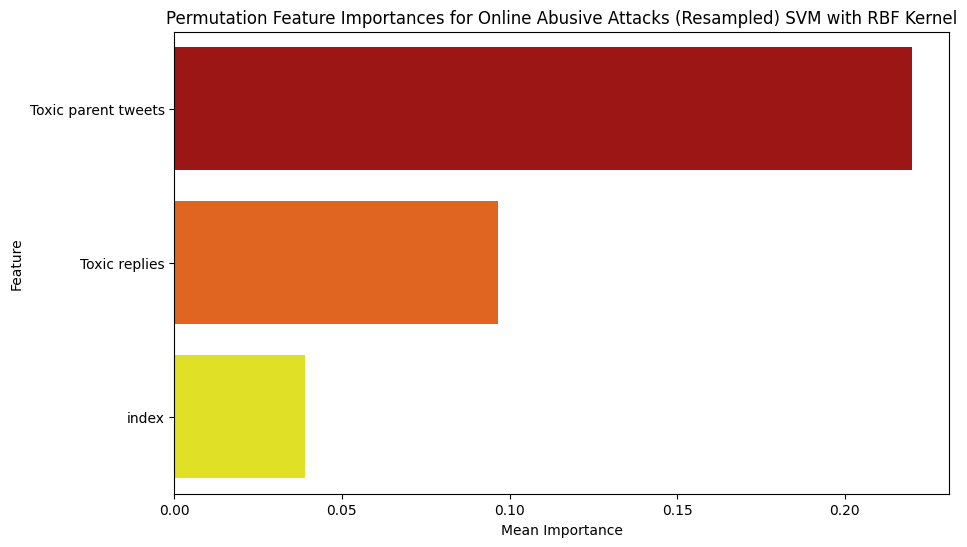

In [107]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance for the RBF kernel SVM model
perm_importance = permutation_importance(oaa_svm_model_rbf, oaa_X_test, oaa_y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Organize the results into a DataFrame
oaa_svm_rbf_perm_importance = pd.DataFrame({
    'feature': oaa_X_test.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

display(oaa_svm_rbf_perm_importance)

# Condense into a dictionary with each feature key and importance mean value
oaa_svm_rbf_perm_importances_dict = oaa_svm_rbf_perm_importance.set_index('feature')['importance_mean'].to_dict()

# Plot the permutation importance
plt.figure(figsize=(10, 6))
sns.barplot(x='importance_mean', y='feature', data=oaa_svm_rbf_perm_importance, palette='hot')
plt.title(f'Permutation Feature Importances for Online Abusive Attacks ({balance}) SVM with RBF Kernel')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.show()

In [108]:
svm_classification_results_list.append(("Online Abusive Attacks", "RBF", "L2", accuracy_score(oaa_y_test, oaa_y_pred_rbf), f1_score(oaa_y_test, oaa_y_pred_rbf, average='weighted'), oaa_svm_rbf_perm_importances_dict))

In [109]:
oaa_custom_param_grid = {
    "C": np.linspace(0.1, 1, 10),
    "kernel": ["linear", "poly", "rbf"],
    "max_iter": range(1, oaa_max_iter), # range(100, 1000, 100),
    "class_weight": [None]
}

In [110]:
# Train and evaluate the SVM model on the US Accidents Upsampled dataset
oaa_custom_svm_grid_search, oaa_custom_svm_model = svm_grid_search(oaa_X_train, oaa_X_test, oaa_y_train, oaa_y_test, oaa_custom_param_grid, oaa_kfold, "oaa_custom_svm_model")

Fitting 5 folds for each of 360 candidates, totalling 1800 fits
Parameters tested for oaa_custom_svm_model:
[{'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 1},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 2},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 3},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 4},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 5},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 6},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 7},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 8},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 9},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 10},
 {'C': np.f

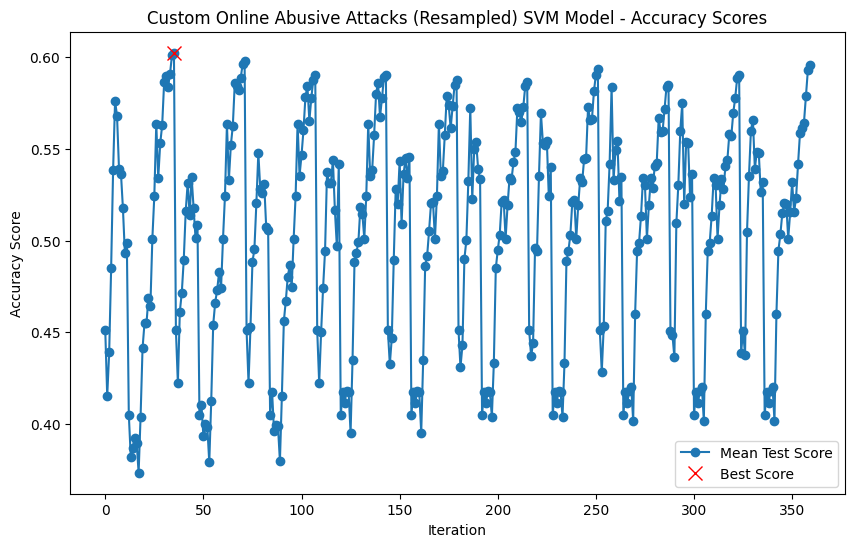

In [111]:
# Plot all accuracy scores for the custom SVM model
plt.figure(figsize=(10, 6))
plt.plot(oaa_custom_svm_grid_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot a red x at the maximum accuracy score
best_oaa_custom_svm_score_index = np.argmax(oaa_custom_svm_grid_search.cv_results_['mean_test_score'])
plt.plot(best_oaa_custom_svm_score_index, oaa_custom_svm_grid_search.cv_results_['mean_test_score'][best_oaa_custom_svm_score_index], 'rx', markersize=10, label='Best Score')

plt.title(f'Custom Online Abusive Attacks ({balance}) SVM Model - Accuracy Scores')
plt.xlabel('Iteration')
plt.ylabel('Accuracy Score')
plt.legend()
plt.show()

In [112]:
# Print the best parameters and score from the grid search using the pickled model
print("Best parameters for SVM with linear kernel and L1 penalty (from pickled model):")
pprint(oaa_custom_svm_grid_search.best_params_)
print("Best score for SVM with linear kernel and L1 penalty (from pickled model):")
print(oaa_custom_svm_grid_search.best_score_)

# Get the best kernel
best_oaa_custom_kernel = oaa_custom_svm_grid_search.best_params_['kernel']
print(f"Best kernel: {best_oaa_custom_kernel}")

Best parameters for SVM with linear kernel and L1 penalty (from pickled model):
{'C': np.float64(0.1), 'class_weight': None, 'kernel': 'rbf', 'max_iter': 12}
Best score for SVM with linear kernel and L1 penalty (from pickled model):
0.6025353572376486
Best kernel: rbf


In [113]:
# Train the SVM model with the best parameters
oaa_custom_svm_best_model = oaa_custom_svm_grid_search.best_estimator_
oaa_custom_svm_best_model.fit(oaa_X_train, oaa_y_train)

SVC(C=np.float64(0.1), max_iter=12)

In [114]:
# Use the model to make predictions on the test set
oaa_custom_y_pred = oaa_custom_svm_model.predict(oaa_X_test)

# Print the classification report
print("Classification report for Online Abusive Attacks Upsampled dataset with L1 regularization:")
print(classification_report(oaa_y_test, oaa_custom_y_pred))

Classification report for Online Abusive Attacks Upsampled dataset with L1 regularization:
              precision    recall  f1-score   support

           0       0.66      0.70      0.68       242
           1       0.44      0.44      0.44       215
           2       0.39      0.55      0.46       199
           3       0.53      0.26      0.35       227
           4       0.82      0.89      0.85       229

    accuracy                           0.57      1112
   macro avg       0.57      0.57      0.55      1112
weighted avg       0.57      0.57      0.56      1112



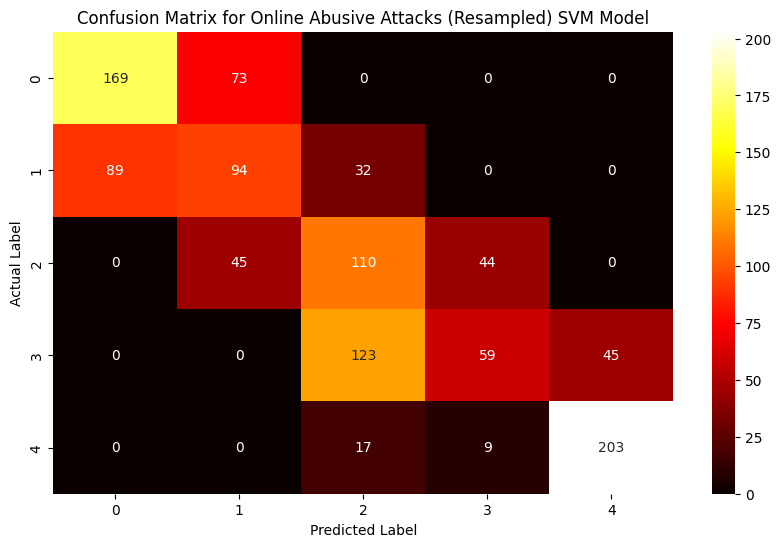

In [115]:
# Plot a heatmap of the predicted vs actual labels
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(oaa_y_test, oaa_custom_y_pred, rownames=['Actual Label'], colnames=['Predicted Label']), annot=True, fmt='d', cmap='hot')
plt.title(f'Confusion Matrix for Online Abusive Attacks ({balance}) SVM Model')
plt.show()

,feature,importance_mean,importance_std
1,Toxic parent tweets,0.335432,0.014875
2,Toxic replies,0.069155,0.007813
0,index,0.010162,0.007251


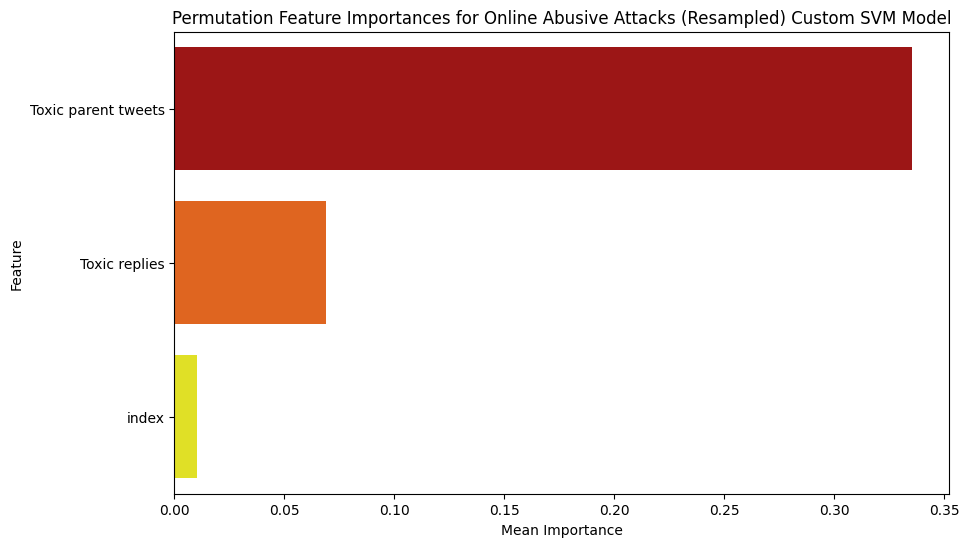

In [116]:
from sklearn.inspection import permutation_importance

# Determine the feature importances using permutation importance
perm_importance = permutation_importance(oaa_custom_svm_best_model, oaa_X_test, oaa_y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Organize the results into a DataFrame
oaa_custom_svm_model_perm_importances = pd.DataFrame({
    'feature': oaa_X_test.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

display(oaa_custom_svm_model_perm_importances)

# Condense into a dictionary with each feature key and importance mean value
oaa_custom_svm_model_perm_importances_dict = oaa_custom_svm_model_perm_importances.set_index('feature')['importance_mean'].to_dict()

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance_mean', y='feature', data=oaa_custom_svm_model_perm_importances, palette='hot')
plt.title(f'Permutation Feature Importances for Online Abusive Attacks ({balance}) Custom SVM Model')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.show()

In [117]:
# Get the custom model's accuracy and f1-score
oaa_custom_accuracy = accuracy_score(oaa_y_test, oaa_custom_y_pred)
oaa_custom_f1_score = f1_score(oaa_y_test, oaa_custom_y_pred, average='weighted')
print(f"Custom SVM Model Accuracy: {oaa_custom_accuracy}")
print(f"Custom SVM Model F1-Score: {oaa_custom_f1_score}")

Custom SVM Model Accuracy: 0.5710431654676259
Custom SVM Model F1-Score: 0.5604315898817525


In [118]:
svm_classification_results_list.append(("Online Abusive Attacks", best_oaa_custom_kernel, "L1", oaa_custom_accuracy, oaa_custom_f1_score, oaa_custom_svm_model_perm_importances_dict))

In [119]:
svm_classification_results_list

[('Convabuse',
  'Linear',
  'L1',
  0.535678791492745,
  0.5138186780532034,
  {'system': 0.11788908765652953,
   'implicit': 0.10230570463128603,
   'explicit': 0.0796660703637448,
   'bot': 0.043589743589743594,
   'annotator_id': 0.01612005565493938,
   'generalised': 0.0,
   'individual': 0.0,
   'target_groups': -0.004830053667262968}),
 ('Convabuse',
  'RBF',
  'L2',
  0.5358775591333731,
  0.519119606435703,
  {'system': 0.22393162393162394,
   'explicit': 0.08547008547008547,
   'target_groups': 0.06022659511031606,
   'implicit': 0.058437686344663106,
   'annotator_id': 0.0385012919896641,
   'bot': 0.03172331544424567,
   'individual': 0.0,
   'generalised': 0.0}),
 ('Convabuse',
  'linear',
  'L1',
  0.4259590538660306,
  0.3676610685029406,
  {'system': 0.1969787318624528,
   'implicit': 0.06692506459948319,
   'individual': 0.0,
   'generalised': 0.0,
   'bot': -0.015026833631484798,
   'explicit': -0.015941164778374074,
   'target_groups': -0.02675412442854303,
   'annot

## US Elections 2020 Hate Speech Support Vector Machines

In [120]:
# Use grid search to find the best hyperparameters for the Linear SVC model
us2020hs_svm_linear_param_grid = {
    'C': np.linspace(0.1, 1, 10), # Regularization parameter
    'loss': ['squared_hinge'], # Loss function
    'max_iter': range(1, us2020hs_max_iter), # range(2, 10), # Maximum number of iterations
    'tol': [1e-4] # Tolerance for stopping criteria
}

In [121]:
us2020hs_svm_linear_grid_search = GridSearchCV(svm.LinearSVC(), us2020hs_svm_linear_param_grid, cv=us2020hs_kfold, scoring='accuracy')
us2020hs_svm_linear_grid_search.fit(us2020hs_X_train, us2020hs_y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LinearSVC(),
             param_grid={'C': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
                         'loss': ['squared_hinge'], 'max_iter': range(1, 13),
                         'tol': [0.0001]},
             scoring='accuracy')

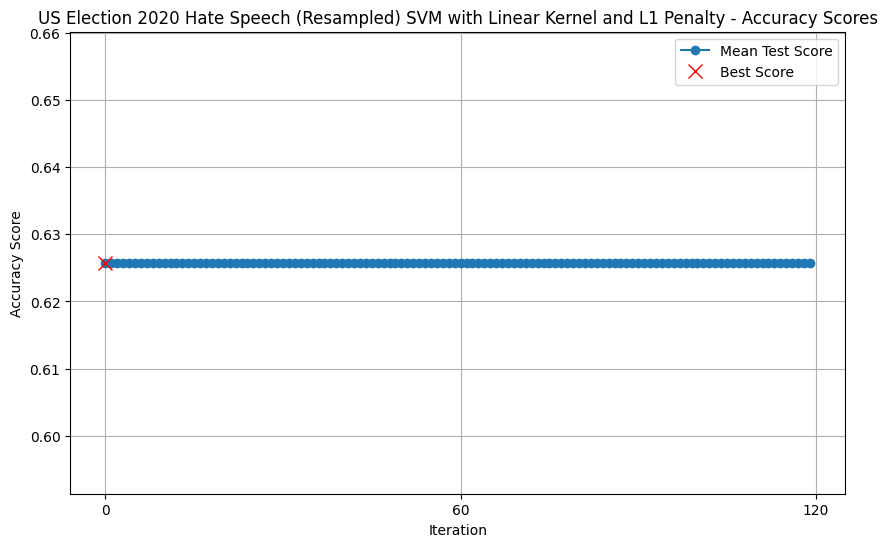

In [122]:
# Plot all accuracy scores for the SVM model with linear kernel and L1 penalty for each iteration
plt.figure(figsize=(10, 6))
plt.plot(us2020hs_svm_linear_grid_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot a red x at the best score
us2020hs_linear_best_score_index = np.argmax(us2020hs_svm_linear_grid_search.cv_results_['mean_test_score'])
plt.plot(us2020hs_linear_best_score_index, us2020hs_svm_linear_grid_search.cv_results_['mean_test_score'][us2020hs_linear_best_score_index], 'rx', markersize=10, label='Best Score')

plt.title(f'US Election 2020 Hate Speech ({balance}) SVM with Linear Kernel and L1 Penalty - Accuracy Scores')
plt.xlabel('Iteration')
plt.ylabel('Accuracy Score')
plt.xticks([0, (len(us2020hs_svm_linear_grid_search.cv_results_['mean_test_score'])) / 2, len(us2020hs_svm_linear_grid_search.cv_results_['mean_test_score'])])
plt.grid()
plt.legend()
plt.show()

In [123]:
# Print the best parameters and score from the grid search
print("Best parameters for SVM with linear kernel and L1 penalty:")
pprint(us2020hs_svm_linear_grid_search.best_params_)
print("Best score for SVM with linear kernel and L1 penalty:")
print(us2020hs_svm_linear_grid_search.best_score_)

Best parameters for SVM with linear kernel and L1 penalty:
{'C': np.float64(0.1), 'loss': 'squared_hinge', 'max_iter': 1, 'tol': 0.0001}
Best score for SVM with linear kernel and L1 penalty:
0.6257688101180628


In [124]:
# Train the SVM model with the best parameters
us2020hs_svm_model_linear = svm.LinearSVC(**us2020hs_svm_linear_grid_search.best_params_, random_state=42)
us2020hs_svm_model_linear.fit(us2020hs_X_train, us2020hs_y_train)

LinearSVC(C=np.float64(0.1), max_iter=1, random_state=42)

In [125]:
# Print the classification report for the us2020hs_svm_model_linear model
us2020hs_y_pred_linear = us2020hs_svm_model_linear.predict(us2020hs_X_test)
print("Classification report for SVM with linear kernel and L1 penalty:")
print(classification_report(us2020hs_y_test, us2020hs_y_pred_linear))
print(f"F1 Score: {f1_score(us2020hs_y_test, us2020hs_y_pred_linear, average='weighted'):.4f}")
print(f"Accuracy: {accuracy_score(us2020hs_y_test, us2020hs_y_pred_linear):.4f}")

Classification report for SVM with linear kernel and L1 penalty:
              precision    recall  f1-score   support

           0       0.64      0.64      0.64       528
           1       0.64      0.64      0.64       528

    accuracy                           0.64      1056
   macro avg       0.64      0.64      0.64      1056
weighted avg       0.64      0.64      0.64      1056

F1 Score: 0.6439
Accuracy: 0.6439


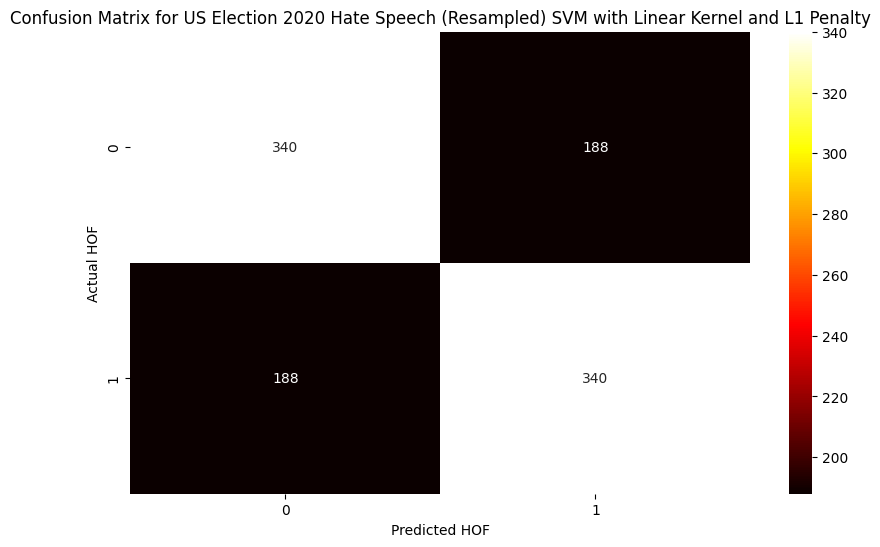

In [126]:
# Plot a heatmap of the actual vs predicted HOF for the us_accidents_svm_model_linear model
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(us2020hs_y_test, us2020hs_y_pred_linear, rownames=['Actual'], colnames=['Predicted']), annot=True, fmt='d', cmap='hot')
plt.title(f'Confusion Matrix for US Election 2020 Hate Speech ({balance}) SVM with Linear Kernel and L1 Penalty')
plt.xlabel('Predicted HOF')
plt.ylabel('Actual HOF')
plt.show()

,feature,importance_mean,importance_std
1,Biden,0.112689,0.007946
0,Trump,0.069318,0.006448
2,West,0.000000,0.000000


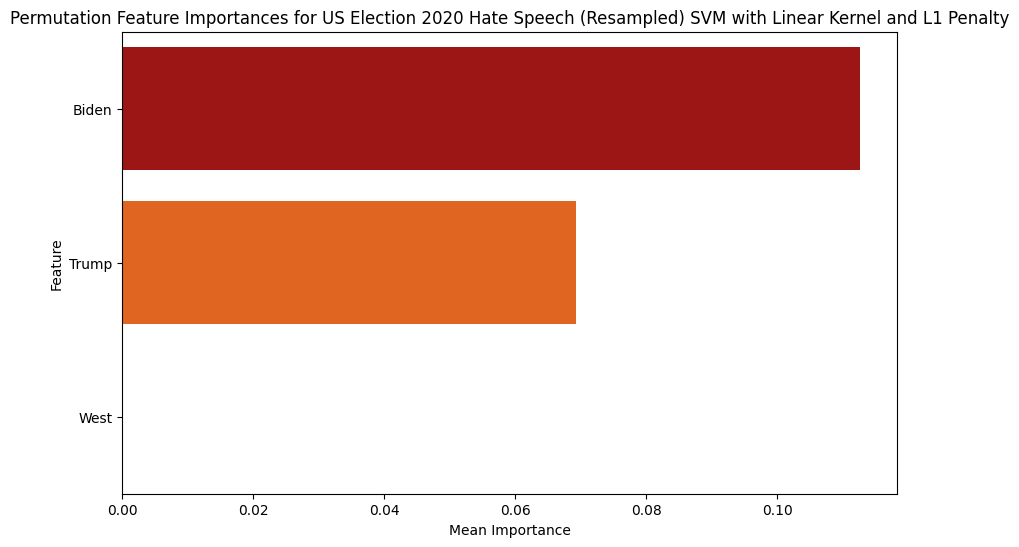

In [127]:
from sklearn.inspection import permutation_importance

# Determine the feature importances
perm_importance = permutation_importance(us2020hs_svm_model_linear, us2020hs_X_test, us2020hs_y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Organize the results into a DataFrame
us2020hs_svm_model_linear_perm_importances = pd.DataFrame({
    'feature': us2020hs_X_test.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

display(us2020hs_svm_model_linear_perm_importances)

# Condense into a dictionary with each feature key and importance mean value
us2020hs_svm_model_linear_perm_importances_dict = us2020hs_svm_model_linear_perm_importances.set_index('feature')['importance_mean'].to_dict()

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance_mean', y='feature', data=us2020hs_svm_model_linear_perm_importances, palette='hot')
plt.title(f'Permutation Feature Importances for US Election 2020 Hate Speech ({balance}) SVM with Linear Kernel and L1 Penalty')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.show()

In [128]:
svm_classification_results_list.append(("US Elections 2020 Election Hate Speech", "Linear", "L1", accuracy_score(us2020hs_y_test, us2020hs_y_pred_linear), f1_score(us2020hs_y_test, us2020hs_y_pred_linear, average='weighted'), us2020hs_svm_model_linear_perm_importances_dict))

In [129]:
us2020hs_svm_rbf_pipeline = Pipeline([
    ("kernel", RBFSampler()),
    ("clf", SGDClassifier(loss="hinge", random_state=42, penalty="l2", tol=1e-4))
])

In [130]:
# Use grid search to find the best hyperparameters for the SVM model
us2020hs_svm_rbf_param_grid = {
    'kernel__gamma': np.linspace(0.1, 1, 10), # Kernel coefficient,
    'kernel__n_components': range(2, us2020hs_X_train.shape[1] + 1), # Number of components for the RBF kernel
    'clf__alpha': [1e-4], # Regularization parameter
    'clf__max_iter': range(1, us2020hs_max_iter), # range(820, 840), # Maximum number of iterations
    'clf__tol': [1e-4], # Tolerance for stopping criteria
    'clf__early_stopping': [True] # Whether to use early stopping
}

In [131]:
# Perform a grid search using the RBFSampler
us2020hs_svm_rbf_grid_search = GridSearchCV(
    estimator=us2020hs_svm_rbf_pipeline,
    param_grid=
    us2020hs_svm_rbf_param_grid,
    cv=us2020hs_kfold,
    scoring='accuracy',
    n_jobs=2,
    verbose=True
)

In [132]:
# Fit the grid search to the training data
us2020hs_svm_rbf_grid_search.fit(us2020hs_X_train, us2020hs_y_train)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('kernel', RBFSampler()),
                                       ('clf',
                                        SGDClassifier(random_state=42,
                                                      tol=0.0001))]),
             n_jobs=2,
             param_grid={'clf__alpha': [0.0001], 'clf__early_stopping': [True],
                         'clf__max_iter': range(1, 13), 'clf__tol': [0.0001],
                         'kernel__gamma': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
                         'kernel__n_components': range(2, 4)},
             scoring='accuracy', verbose=True)

In [133]:
# Print the best parameters and score from the grid search
print("Best parameters for SVM with RBF kernel:")
pprint(us2020hs_svm_rbf_grid_search.best_params_)
print("Best score for SVM with RBF kernel:")
print(us2020hs_svm_rbf_grid_search.best_score_)

Best parameters for SVM with RBF kernel:
{'clf__alpha': 0.0001,
 'clf__early_stopping': True,
 'clf__max_iter': 12,
 'clf__tol': 0.0001,
 'kernel__gamma': np.float64(0.2),
 'kernel__n_components': 3}
Best score for SVM with RBF kernel:
0.664374772147284


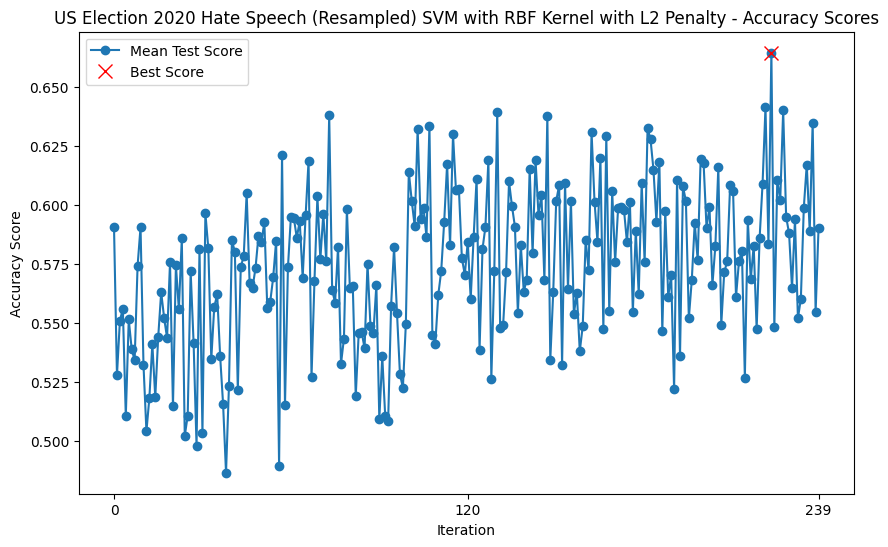

In [134]:
# Plot all accuracy scores for the SVM model with RBF kernel for each iteration
plt.figure(figsize=(10, 6))
plt.plot(us2020hs_svm_rbf_grid_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot a red x at the best score
best_us2020hs_svm_rbf_score_index = np.argmax(us2020hs_svm_rbf_grid_search.cv_results_['mean_test_score'])
plt.plot(best_us2020hs_svm_rbf_score_index, us2020hs_svm_rbf_grid_search.cv_results_['mean_test_score'][best_us2020hs_svm_rbf_score_index], 'rx', markersize=10, label='Best Score')

plt.title(f'US Election 2020 Hate Speech ({balance}) SVM with RBF Kernel with L2 Penalty - Accuracy Scores')
plt.xlabel('Iteration')
plt.ylabel('Accuracy Score')

# Only plot x-axis ticks of 0, the median, and the last iteration
plt.xticks([0, len(us2020hs_svm_rbf_grid_search.cv_results_['mean_test_score']) // 2, len(us2020hs_svm_rbf_grid_search.cv_results_['mean_test_score']) - 1])

plt.legend()
plt.show()

In [135]:
# Train the SVM model with the best parameters
us2020hs_svm_model_rbf = us2020hs_svm_rbf_grid_search.best_estimator_
us2020hs_svm_model_rbf.fit(us2020hs_X_train, us2020hs_y_train)

Pipeline(steps=[('kernel', RBFSampler(gamma=np.float64(0.2), n_components=3)),
                ('clf',
                 SGDClassifier(early_stopping=True, max_iter=12,
                               random_state=42, tol=0.0001))])

In [136]:
# Print the classification report for the us2020hs_svm_model_rbf model
us2020hs_y_pred_rbf = us2020hs_svm_model_rbf.predict(us2020hs_X_test)
print("Classification report for SVM with RBF kernel:")
print(classification_report(us2020hs_y_test, us2020hs_y_pred_rbf))
print(f"F1 Score: {f1_score(us2020hs_y_test, us2020hs_y_pred_rbf, average='weighted'):.4f}")
print(f"Accuracy: {accuracy_score(us2020hs_y_test, us2020hs_y_pred_rbf):.4f}")

Classification report for SVM with RBF kernel:
              precision    recall  f1-score   support

           0       0.64      0.68      0.66       528
           1       0.66      0.62      0.64       528

    accuracy                           0.65      1056
   macro avg       0.65      0.65      0.65      1056
weighted avg       0.65      0.65      0.65      1056

F1 Score: 0.6493
Accuracy: 0.6496


In [137]:
us2020hs_y_test.value_counts()

,count
HOF,
1,528
0,528


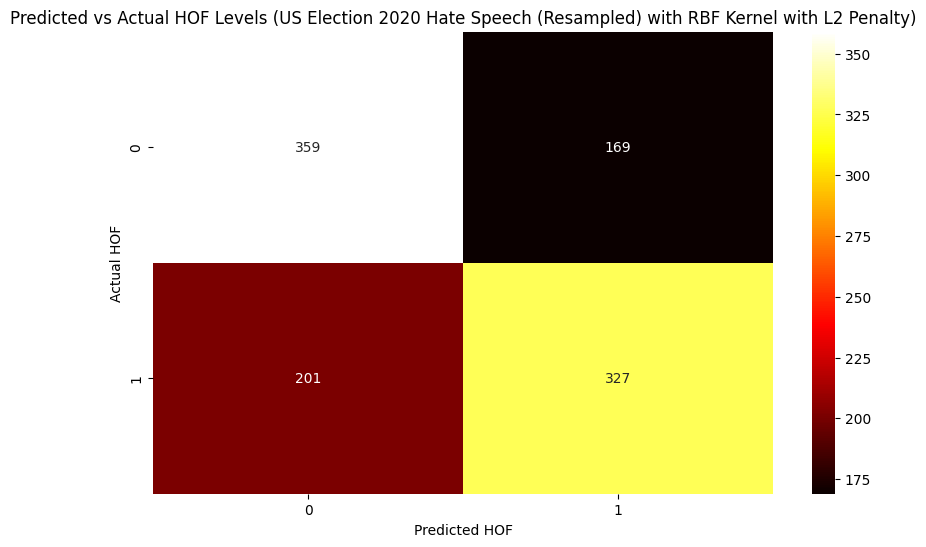

In [138]:
# Plot a heatmap of the predicted vs actual HOF levels
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(us2020hs_y_test, us2020hs_y_pred_rbf), annot=True, fmt='d', cmap='hot')
plt.title(f'Predicted vs Actual HOF Levels (US Election 2020 Hate Speech ({balance}) with RBF Kernel with L2 Penalty)')
plt.xlabel('Predicted HOF')
plt.ylabel('Actual HOF')
plt.show()

,feature,importance_mean,importance_std
0,Trump,0.108902,0.011173
1,Biden,0.068561,0.008936
2,West,0.000000,0.000000


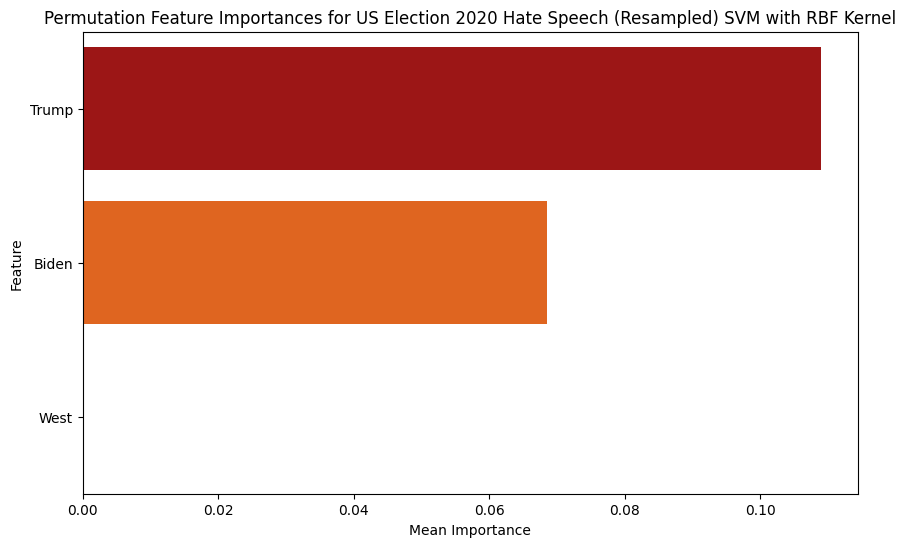

In [139]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance for the RBF kernel SVM model
perm_importance = permutation_importance(us2020hs_svm_model_rbf, us2020hs_X_test, us2020hs_y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Organize the results into a DataFrame
us2020hs_svm_rbf_perm_importance = pd.DataFrame({
    'feature': us2020hs_X_test.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

display(us2020hs_svm_rbf_perm_importance)

# Condense into a dictionary with each feature key and importance mean value
us2020hs_svm_rbf_perm_importances_dict = us2020hs_svm_rbf_perm_importance.set_index('feature')['importance_mean'].to_dict()

# Plot the permutation importance
plt.figure(figsize=(10, 6))
sns.barplot(x='importance_mean', y='feature', data=us2020hs_svm_rbf_perm_importance, palette='hot')
plt.title(f'Permutation Feature Importances for US Election 2020 Hate Speech ({balance}) SVM with RBF Kernel')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.show()

In [140]:
svm_classification_results_list.append(("US Elections 2020 Election Hate Speech", "RBF", "L2", accuracy_score(us2020hs_y_test, us2020hs_y_pred_rbf), f1_score(us2020hs_y_test, us2020hs_y_pred_rbf, average='weighted'), us2020hs_svm_rbf_perm_importances_dict))

In [141]:
us2020hs_custom_param_grid = {
    "C": np.linspace(0.1, 1, 10),
    "kernel": ["linear", "poly", "rbf"],
    "max_iter": range(1, us2020hs_max_iter), # range(160, 200),
    "class_weight": ["balanced", None]
}

In [142]:
# Train and evaluate the SVM model on the US Accidents Upsampled dataset
us2020hs_custom_svm_grid_search, us2020hs_custom_svm_model = svm_grid_search(us2020hs_X_train, us2020hs_X_test, us2020hs_y_train, us2020hs_y_test, us2020hs_custom_param_grid, us2020hs_kfold, "us2020hs_custom_svm_model")

Fitting 5 folds for each of 720 candidates, totalling 3600 fits
Parameters tested for us2020hs_custom_svm_model:
[{'C': np.float64(0.1),
  'class_weight': 'balanced',
  'kernel': 'linear',
  'max_iter': 1},
 {'C': np.float64(0.1),
  'class_weight': 'balanced',
  'kernel': 'linear',
  'max_iter': 2},
 {'C': np.float64(0.1),
  'class_weight': 'balanced',
  'kernel': 'linear',
  'max_iter': 3},
 {'C': np.float64(0.1),
  'class_weight': 'balanced',
  'kernel': 'linear',
  'max_iter': 4},
 {'C': np.float64(0.1),
  'class_weight': 'balanced',
  'kernel': 'linear',
  'max_iter': 5},
 {'C': np.float64(0.1),
  'class_weight': 'balanced',
  'kernel': 'linear',
  'max_iter': 6},
 {'C': np.float64(0.1),
  'class_weight': 'balanced',
  'kernel': 'linear',
  'max_iter': 7},
 {'C': np.float64(0.1),
  'class_weight': 'balanced',
  'kernel': 'linear',
  'max_iter': 8},
 {'C': np.float64(0.1),
  'class_weight': 'balanced',
  'kernel': 'linear',
  'max_iter': 9},
 {'C': np.float64(0.1),
  'class_weight':

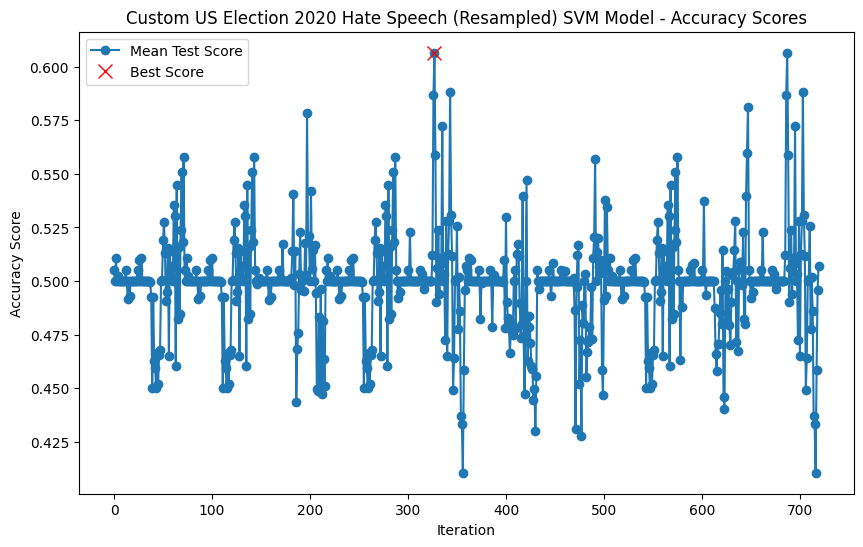

In [143]:
# Plot all accuracy scores for the custom SVM model
plt.figure(figsize=(10, 6))
plt.plot(us2020hs_custom_svm_grid_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot a red x at the maximum accuracy score
best_us2020hs_custom_svm_score_index = np.argmax(us2020hs_custom_svm_grid_search.cv_results_['mean_test_score'])
plt.plot(best_us2020hs_custom_svm_score_index, us2020hs_custom_svm_grid_search.cv_results_['mean_test_score'][best_us2020hs_custom_svm_score_index], 'rx', markersize=10, label='Best Score')

plt.title(f'Custom US Election 2020 Hate Speech ({balance}) SVM Model - Accuracy Scores')
plt.xlabel('Iteration')
plt.ylabel('Accuracy Score')
plt.legend()
plt.show()

In [144]:
# Print the best parameters and score from the grid search
print("Best parameters for SVM with linear kernel and L1 penalty:")
pprint(us2020hs_custom_svm_grid_search.best_params_)
print("Best score for SVM with linear kernel and L1 penalty:")
print(us2020hs_custom_svm_grid_search.best_score_)

# Get the best kernel
best_us2020hs_custom_kernel = us2020hs_custom_svm_grid_search.best_params_['kernel']

Best parameters for SVM with linear kernel and L1 penalty:
{'C': np.float64(0.5), 'class_weight': None, 'kernel': 'linear', 'max_iter': 4}
Best score for SVM with linear kernel and L1 penalty:
0.6065784233994224


In [145]:
# Train the SVM model with the best parameters
us2020hs_custom_svm_best_params = us2020hs_custom_svm_grid_search.best_params_.copy()
us2020hs_custom_svm_best_params.pop('kernel', None) # Remove the kernel key if it exists
us2020hs_custom_svm_best_model = us2020hs_custom_svm_grid_search.best_estimator_
us2020hs_custom_svm_best_model.fit(us2020hs_X_train, us2020hs_y_train)

SVC(C=np.float64(0.5), kernel='linear', max_iter=4)

In [146]:
# Use the model to make predictions on the test set
us2020hs_custom_y_pred = us2020hs_custom_svm_best_model.predict(us2020hs_X_test)

# Print the classification report
print("Classification report for US Accidents Upsampled dataset with L1 regularization:")
print(classification_report(us2020hs_y_test, us2020hs_custom_y_pred))

Classification report for US Accidents Upsampled dataset with L1 regularization:
              precision    recall  f1-score   support

           0       0.70      0.57      0.63       528
           1       0.64      0.75      0.69       528

    accuracy                           0.66      1056
   macro avg       0.67      0.66      0.66      1056
weighted avg       0.67      0.66      0.66      1056



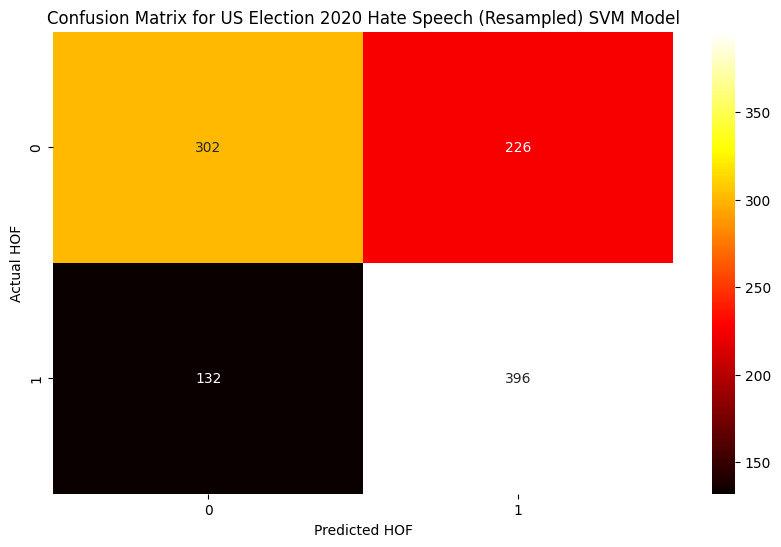

In [147]:
# Plot a heatmap of the predicted vs actual HOF levels
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(us2020hs_y_test, us2020hs_custom_y_pred, rownames=['Actual HOF'], colnames=['Predicted HOF']), annot=True, fmt='d', cmap='hot')
plt.title(f'Confusion Matrix for US Election 2020 Hate Speech ({balance}) SVM Model')
plt.show()

,feature,importance_mean,importance_std
0,Trump,0.130777,0.013335
1,Biden,0.121591,0.008440
2,West,0.000000,0.000000


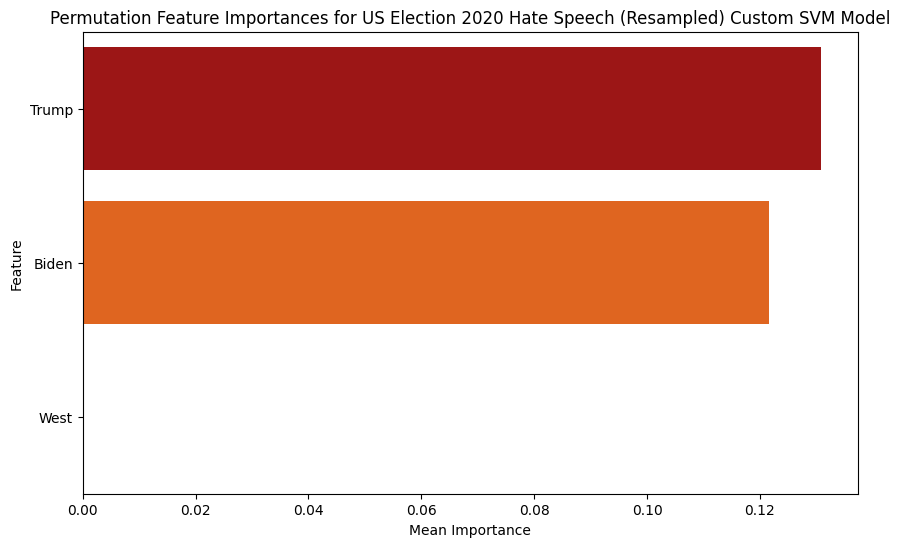

In [148]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance for the RBF kernel SVM model
perm_importance = permutation_importance(us2020hs_custom_svm_best_model, us2020hs_X_test, us2020hs_y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Organize the results into a DataFrame
us2020hs_custom_svm_perm_importances = pd.DataFrame({
    'feature': us2020hs_X_test.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

display(us2020hs_custom_svm_perm_importances)

# Condense into a dictionary with each feature key and importance mean value
us2020hs_custom_svm_perm_importances_dict = us2020hs_custom_svm_perm_importances.set_index('feature')['importance_mean'].to_dict()

# Plot the permutation importance
plt.figure(figsize=(10, 6))
sns.barplot(x='importance_mean', y='feature', data=us2020hs_custom_svm_perm_importances, palette='hot')
plt.title(f'Permutation Feature Importances for US Election 2020 Hate Speech ({balance}) Custom SVM Model')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.show()

In [149]:
# Get the custom model's accuracy and f1-score
us2020hs_custom_accuracy = accuracy_score(us2020hs_y_test, us2020hs_custom_y_pred)
us2020hs_custom_f1_score = f1_score(us2020hs_y_test, us2020hs_custom_y_pred, average='weighted')
print(f"Custom SVM Model Accuracy: {us2020hs_custom_accuracy}")
print(f"Custom SVM Model F1-Score: {us2020hs_custom_f1_score}")

Custom SVM Model Accuracy: 0.6609848484848485
Custom SVM Model F1-Score: 0.6582771400162705


In [150]:
svm_classification_results_list.append(("US Elections 2020 Election Hate Speech", best_us2020hs_custom_kernel, "L1", us2020hs_custom_accuracy, us2020hs_custom_f1_score, us2020hs_custom_svm_perm_importances_dict))

In [151]:
svm_classification_results_list

[('Convabuse',
  'Linear',
  'L1',
  0.535678791492745,
  0.5138186780532034,
  {'system': 0.11788908765652953,
   'implicit': 0.10230570463128603,
   'explicit': 0.0796660703637448,
   'bot': 0.043589743589743594,
   'annotator_id': 0.01612005565493938,
   'generalised': 0.0,
   'individual': 0.0,
   'target_groups': -0.004830053667262968}),
 ('Convabuse',
  'RBF',
  'L2',
  0.5358775591333731,
  0.519119606435703,
  {'system': 0.22393162393162394,
   'explicit': 0.08547008547008547,
   'target_groups': 0.06022659511031606,
   'implicit': 0.058437686344663106,
   'annotator_id': 0.0385012919896641,
   'bot': 0.03172331544424567,
   'individual': 0.0,
   'generalised': 0.0}),
 ('Convabuse',
  'linear',
  'L1',
  0.4259590538660306,
  0.3676610685029406,
  {'system': 0.1969787318624528,
   'implicit': 0.06692506459948319,
   'individual': 0.0,
   'generalised': 0.0,
   'bot': -0.015026833631484798,
   'explicit': -0.015941164778374074,
   'target_groups': -0.02675412442854303,
   'annot

## MLMA Hate Speech Support Vector Machines

In [152]:
# Use grid search to find the best hyperparameters for the Linear SVC model
mlma_hate_speech_svm_linear_param_grid = {
    'C': np.linspace(0.1, 1, 10), # Regularization parameter
    'loss': ['squared_hinge'], # Loss function
    'max_iter': range(1, mlma_hate_speech_max_iter), # range(2, 10), # Maximum number of iterations
    'tol': [1e-4] # Tolerance for stopping criteria
}

In [153]:
# Get a 30% sample of mlma_hate_speech
mlma_hate_speech_sample = mlma_hate_speech.sample(frac=0.3, random_state=42)

# X and y
mlma_hate_speech_X_sample = mlma_hate_speech_sample.drop('target_groups', axis=1)
mlma_hate_speech_y_sample = mlma_hate_speech_sample['target_groups']

# Standard scale
mlma_hate_speech_X_sample_scaled = StandardScaler().fit_transform(mlma_hate_speech_X_sample)
mlma_hate_speech_X_sample_scaled = pd.DataFrame(mlma_hate_speech_X_sample_scaled, columns=mlma_hate_speech_X_sample.columns)

# Train test split
mlma_hate_speech_X_train_sample, mlma_hate_speech_X_test_sample, mlma_hate_speech_y_train_sample, mlma_hate_speech_y_test_sample = train_test_split(mlma_hate_speech_X_sample_scaled, mlma_hate_speech_y_sample, test_size=0.2, random_state=42)

In [154]:
mlma_hate_speech_svm_linear_grid_search = GridSearchCV(svm.LinearSVC(), mlma_hate_speech_svm_linear_param_grid, cv=mlma_hate_speech_kfold, scoring='accuracy')
mlma_hate_speech_svm_linear_grid_search.fit(mlma_hate_speech_X_train_sample, mlma_hate_speech_y_train_sample)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LinearSVC(),
             param_grid={'C': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
                         'loss': ['squared_hinge'], 'max_iter': range(1, 15),
                         'tol': [0.0001]},
             scoring='accuracy')

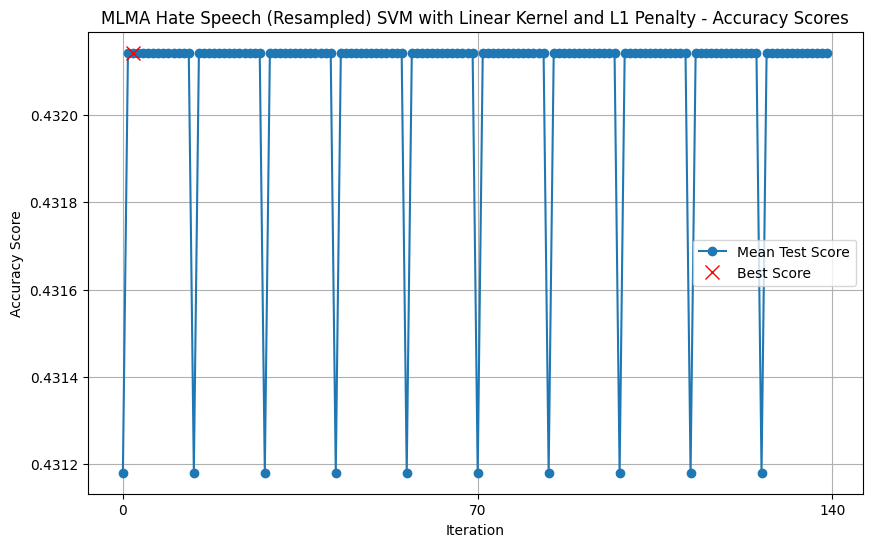

In [155]:
# Plot all accuracy scores for the SVM model with linear kernel and L1 penalty for each iteration
plt.figure(figsize=(10, 6))
plt.plot(mlma_hate_speech_svm_linear_grid_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot a red x at the best score
mlma_hate_speech_linear_best_score_index = np.argmax(mlma_hate_speech_svm_linear_grid_search.cv_results_['mean_test_score'])
plt.plot(mlma_hate_speech_linear_best_score_index, mlma_hate_speech_svm_linear_grid_search.cv_results_['mean_test_score'][mlma_hate_speech_linear_best_score_index], 'rx', markersize=10, label='Best Score')

plt.title(f'MLMA Hate Speech ({balance}) SVM with Linear Kernel and L1 Penalty - Accuracy Scores')
plt.xlabel('Iteration')
plt.ylabel('Accuracy Score')
plt.xticks([0, len(mlma_hate_speech_svm_linear_grid_search.cv_results_['mean_test_score']) / 2, len(mlma_hate_speech_svm_linear_grid_search.cv_results_['mean_test_score'])])
plt.grid()
plt.legend()
plt.show()

In [156]:
# Print the best parameters and score from the grid search
print("Best parameters for SVM with linear kernel and L1 penalty:")
pprint(mlma_hate_speech_svm_linear_grid_search.best_params_)
print("Best score for SVM with linear kernel and L1 penalty:")
print(mlma_hate_speech_svm_linear_grid_search.best_score_)

Best parameters for SVM with linear kernel and L1 penalty:
{'C': np.float64(0.1), 'loss': 'squared_hinge', 'max_iter': 3, 'tol': 0.0001}
Best score for SVM with linear kernel and L1 penalty:
0.43214272519027563


In [157]:
# Train the SVM model with the best parameters
mlma_hate_speech_svm_model_linear = svm.LinearSVC(**mlma_hate_speech_svm_linear_grid_search.best_params_, random_state=42)
mlma_hate_speech_svm_model_linear.fit(mlma_hate_speech_X_train_sample, mlma_hate_speech_y_train_sample)

LinearSVC(C=np.float64(0.1), max_iter=3, random_state=42)

In [158]:
# Print the classification report for the mlma_hate_speech_svm_model_linear model
mlma_hate_speech_y_pred_linear = mlma_hate_speech_svm_model_linear.predict(mlma_hate_speech_X_test_sample)
print("Classification report for SVM with linear kernel and L1 penalty:")
print(classification_report(mlma_hate_speech_y_test_sample, mlma_hate_speech_y_pred_linear))
print(f"F1 Score: {f1_score(mlma_hate_speech_y_test_sample, mlma_hate_speech_y_pred_linear, average='weighted'):.4f}")
print(f"Accuracy: {accuracy_score(mlma_hate_speech_y_test_sample, mlma_hate_speech_y_pred_linear):.4f}")

Classification report for SVM with linear kernel and L1 penalty:
              precision    recall  f1-score   support

           0       0.41      0.56      0.47       317
           1       0.35      0.15      0.21       334
           2       0.33      0.30      0.32       341
           3       0.53      0.70      0.60       309

    accuracy                           0.42      1301
   macro avg       0.41      0.43      0.40      1301
weighted avg       0.40      0.42      0.40      1301

F1 Score: 0.3965
Accuracy: 0.4220


In [159]:
len(mlma_hate_speech_X_train), len(mlma_hate_speech_y_train), len(mlma_hate_speech_y_pred_linear)

(17340, 17340, 1301)

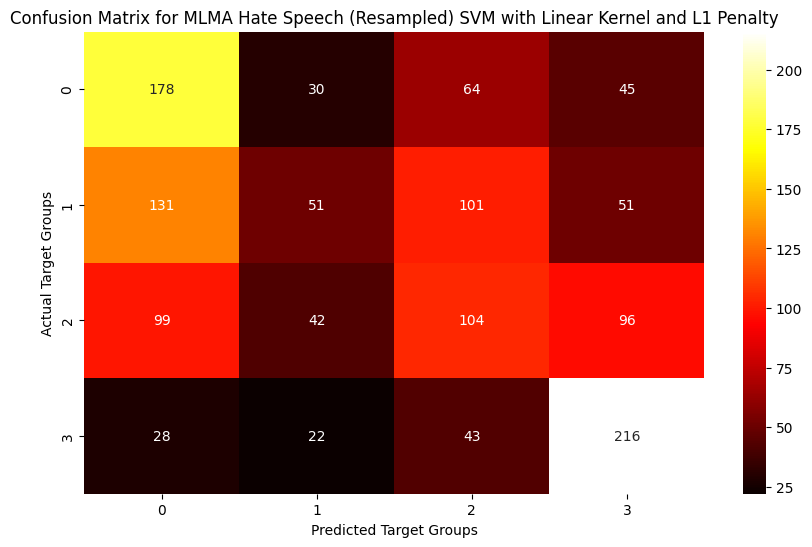

In [160]:
# Plot a heatmap of the actual vs predicted HOF for the mlma_hate_speech_svm_model_linear model
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(mlma_hate_speech_y_test_sample, mlma_hate_speech_y_pred_linear, rownames=['Actual'], colnames=['Predicted']), annot=True, fmt='d', cmap='hot')
plt.title(f'Confusion Matrix for MLMA Hate Speech ({balance}) SVM with Linear Kernel and L1 Penalty')
plt.xlabel('Predicted Target Groups')
plt.ylabel('Actual Target Groups')
plt.show()

,feature,importance_mean,importance_std
0,index,0.063643,0.008916
3,annotator_sentiment,0.036818,0.005601
1,implicit,0.024366,0.005370
2,explicit,0.024366,0.005370
4,abuse_level,0.007610,0.003693


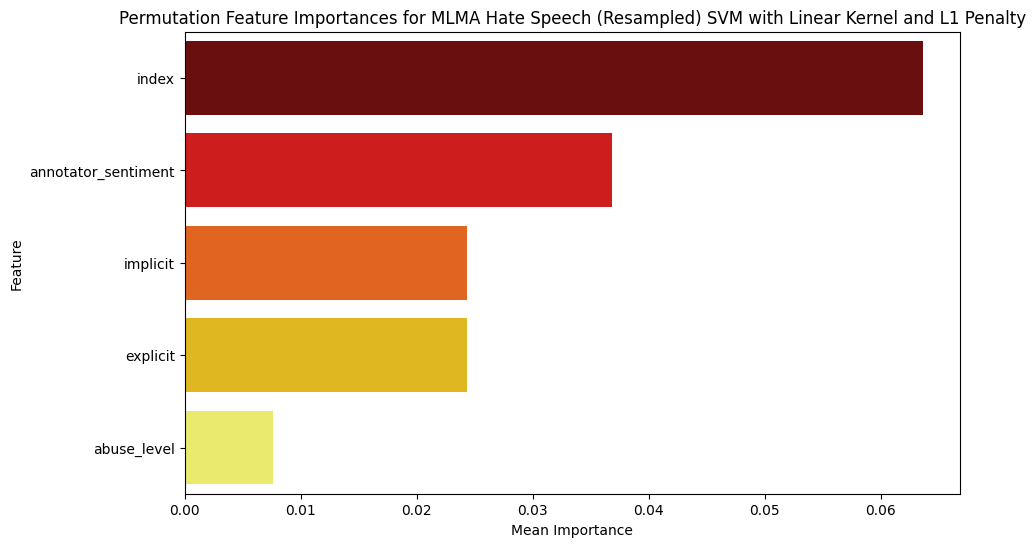

In [162]:
# Determine the feature importances
from sklearn.inspection import permutation_importance

# Calculate permutation importance for the RBF kernel SVM model
perm_importance = permutation_importance(mlma_hate_speech_svm_model_linear, mlma_hate_speech_X_test_sample, mlma_hate_speech_y_test_sample, n_repeats=10, random_state=42, n_jobs=-1)

# Organize the results into a DataFrame
mlma_hate_speech_svm_model_linear_perm_importances = pd.DataFrame({
    'feature': mlma_hate_speech_X_test_sample.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

display(mlma_hate_speech_svm_model_linear_perm_importances)

# Condense into a dictionary with each feature key and importance mean value
mlma_hate_speech_svm_model_linear_perm_importances_dict = mlma_hate_speech_svm_model_linear_perm_importances.set_index('feature')['importance_mean'].to_dict()

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance_mean', y='feature', data=mlma_hate_speech_svm_model_linear_perm_importances, palette='hot')
plt.title(f'Permutation Feature Importances for MLMA Hate Speech ({balance}) SVM with Linear Kernel and L1 Penalty')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.show()

In [164]:
svm_classification_results_list.append(("MLMA Hate Speech", "Linear", "L1", accuracy_score(mlma_hate_speech_y_test_sample, mlma_hate_speech_y_pred_linear), f1_score(mlma_hate_speech_y_test_sample, mlma_hate_speech_y_pred_linear, average='weighted'), mlma_hate_speech_svm_model_linear_perm_importances_dict))

In [165]:
mlma_hate_speech_svm_rbf_pipeline = Pipeline([
    ("kernel", RBFSampler()),
    ("clf", SGDClassifier(loss="hinge", random_state=42, penalty="l2", tol=1e-4))
])

In [166]:
mlma_hate_speech_max_iter

15

In [167]:
# Use grid search to find the best hyperparameters for the SVM model
mlma_hate_speech_svm_rbf_param_grid = {
    'kernel__gamma': np.linspace(0.1, 1, 10), # Kernel coefficient,
    'kernel__n_components': range(2, mlma_hate_speech_X_train.shape[1] + 1), # Number of components for the RBF kernel
    'clf__alpha': [1e-4], # Regularization parameter
    'clf__max_iter': range(1, mlma_hate_speech_max_iter), # range(470, 495, 5), # Maximum number of iterations
    'clf__tol': [1e-4], # Tolerance for stopping criteria
    'clf__early_stopping': [True] # Whether to use early stopping
}

In [168]:
# Perform a grid search using the RBFSampler
mlma_hate_speech_svm_rbf_grid_search = GridSearchCV(
    estimator=mlma_hate_speech_svm_rbf_pipeline,
    param_grid=
    mlma_hate_speech_svm_rbf_param_grid,
    cv=mlma_hate_speech_kfold,
    scoring='accuracy',
    n_jobs=2,
    verbose=True
)

In [169]:
# Fit the grid search to the training data
mlma_hate_speech_svm_rbf_grid_search.fit(mlma_hate_speech_X_train, mlma_hate_speech_y_train)

Fitting 5 folds for each of 420 candidates, totalling 2100 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('kernel', RBFSampler()),
                                       ('clf',
                                        SGDClassifier(random_state=42,
                                                      tol=0.0001))]),
             n_jobs=2,
             param_grid={'clf__alpha': [0.0001], 'clf__early_stopping': [True],
                         'clf__max_iter': range(1, 15), 'clf__tol': [0.0001],
                         'kernel__gamma': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
                         'kernel__n_components': range(2, 5)},
             scoring='accuracy', verbose=True)

In [170]:
# Print the best parameters and score from the grid search
print("Best parameters for SVM with RBF kernel:")
pprint(mlma_hate_speech_svm_rbf_grid_search.best_params_)
print("Best score for SVM with RBF kernel:")
print(mlma_hate_speech_svm_rbf_grid_search.best_score_)

Best parameters for SVM with RBF kernel:
{'clf__alpha': 0.0001,
 'clf__early_stopping': True,
 'clf__max_iter': 13,
 'clf__tol': 0.0001,
 'kernel__gamma': np.float64(0.2),
 'kernel__n_components': 4}
Best score for SVM with RBF kernel:
0.3820069204152249


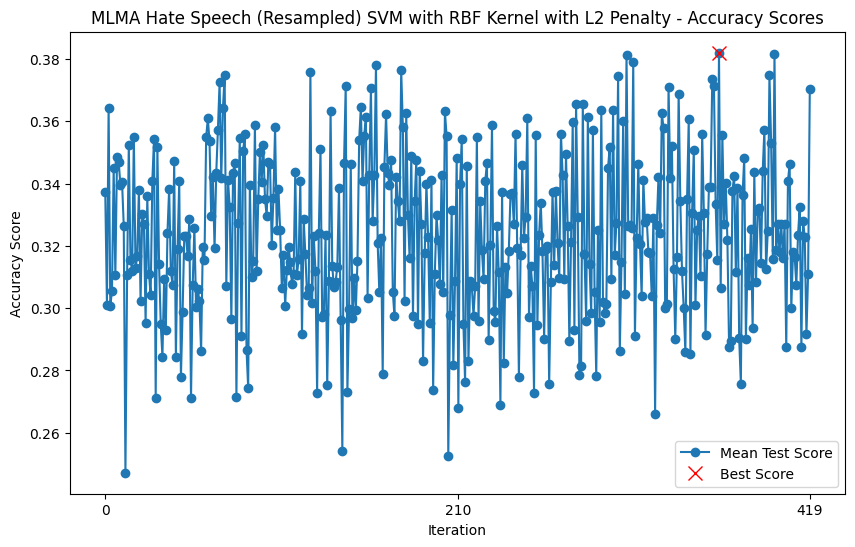

In [171]:
# Plot all accuracy scores for the SVM model with RBF kernel for each iteration
plt.figure(figsize=(10, 6))
plt.plot(mlma_hate_speech_svm_rbf_grid_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot a red x at the best score
best_mlma_hate_speech_svm_rbf_score_index = np.argmax(mlma_hate_speech_svm_rbf_grid_search.cv_results_['mean_test_score'])
plt.plot(best_mlma_hate_speech_svm_rbf_score_index, mlma_hate_speech_svm_rbf_grid_search.cv_results_['mean_test_score'][best_mlma_hate_speech_svm_rbf_score_index], 'rx', markersize=10, label='Best Score')

plt.title(f'MLMA Hate Speech ({balance}) SVM with RBF Kernel with L2 Penalty - Accuracy Scores')
plt.xlabel('Iteration')
plt.ylabel('Accuracy Score')

# Only plot x-axis ticks of 0, the median, and the last iteration
plt.xticks([0, len(mlma_hate_speech_svm_rbf_grid_search.cv_results_['mean_test_score']) // 2, len(mlma_hate_speech_svm_rbf_grid_search.cv_results_['mean_test_score']) - 1])

plt.legend()
plt.show()

In [172]:
# Train the SVM model with the best parameters
mlma_hate_speech_svm_model_rbf = mlma_hate_speech_svm_rbf_grid_search.best_estimator_
mlma_hate_speech_svm_model_rbf.fit(mlma_hate_speech_X_train, mlma_hate_speech_y_train)

Pipeline(steps=[('kernel', RBFSampler(gamma=np.float64(0.2), n_components=4)),
                ('clf',
                 SGDClassifier(early_stopping=True, max_iter=13,
                               random_state=42, tol=0.0001))])

In [173]:
# Print the classification report for the mlma_hate_speech_svm_model_rbf model
mlma_hate_speech_y_pred_rbf = mlma_hate_speech_svm_model_rbf.predict(mlma_hate_speech_X_test)
print("Classification report for SVM with RBF kernel:")
print(classification_report(mlma_hate_speech_y_test, mlma_hate_speech_y_pred_rbf))
print(f"F1 Score: {f1_score(mlma_hate_speech_y_test, mlma_hate_speech_y_pred_rbf, average='weighted'):.4f}")
print(f"Accuracy: {accuracy_score(mlma_hate_speech_y_test, mlma_hate_speech_y_pred_rbf):.4f}")

Classification report for SVM with RBF kernel:
              precision    recall  f1-score   support

           0       0.17      0.00      0.00      1084
           1       0.24      0.90      0.38      1084
           2       0.36      0.10      0.15      1084
           3       0.04      0.00      0.00      1084

    accuracy                           0.25      4336
   macro avg       0.20      0.25      0.14      4336
weighted avg       0.20      0.25      0.14      4336

F1 Score: 0.1361
Accuracy: 0.2512


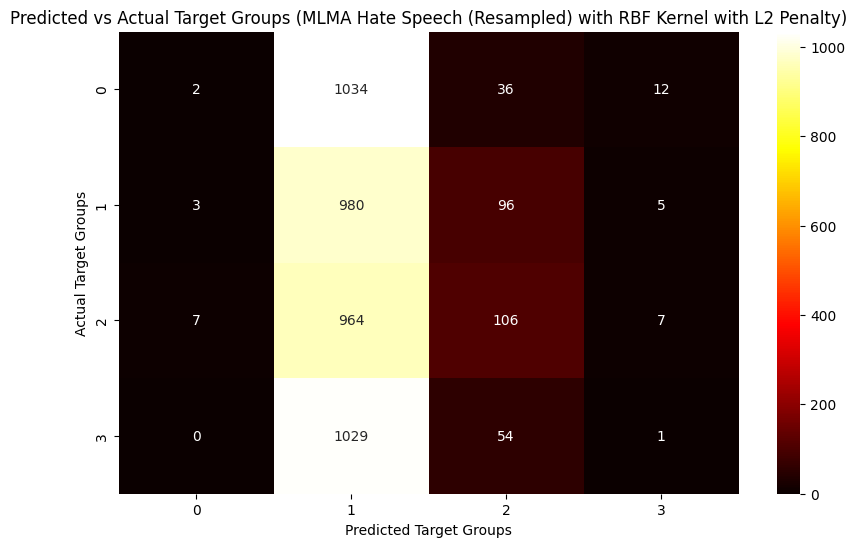

In [174]:
# Plot a heatmap of the predicted vs actual HOF levels
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(mlma_hate_speech_y_test, mlma_hate_speech_y_pred_rbf), annot=True, fmt='d', cmap='hot')
plt.title(f'Predicted vs Actual Target Groups (MLMA Hate Speech ({balance}) with RBF Kernel with L2 Penalty)')
plt.xlabel('Predicted Target Groups')
plt.ylabel('Actual Target Groups')
plt.show()

,feature,importance_mean,importance_std
0,implicit,0.002237,0.001533
2,annotator_sentiment,0.001153,0.001052
1,explicit,-0.001268,0.001213
3,abuse_level,-0.002145,0.002783


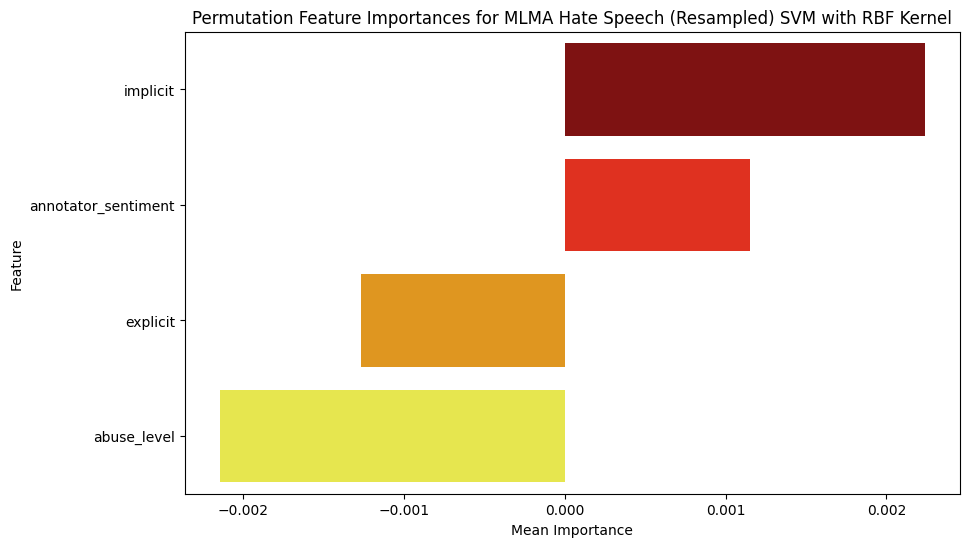

In [175]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance for the RBF kernel SVM model
perm_importance = permutation_importance(mlma_hate_speech_svm_model_rbf, mlma_hate_speech_X_test, mlma_hate_speech_y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Organize the results into a DataFrame
mlma_hate_speech_svm_rbf_perm_importances = pd.DataFrame({
    'feature': mlma_hate_speech_X_test.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

display(mlma_hate_speech_svm_rbf_perm_importances)

# Condense into a dictionary with each feature key and importance mean value
mlma_hate_speech_svm_rbf_perm_importances_dict = mlma_hate_speech_svm_rbf_perm_importances.set_index('feature')['importance_mean'].to_dict()

# Plot the permutation importance
plt.figure(figsize=(10, 6))
sns.barplot(x='importance_mean', y='feature', data=mlma_hate_speech_svm_rbf_perm_importances, palette='hot')
plt.title(f'Permutation Feature Importances for MLMA Hate Speech ({balance}) SVM with RBF Kernel')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.show()

In [176]:
svm_classification_results_list.append(("MLMA Hate Speech", "RBF", "L2", accuracy_score(mlma_hate_speech_y_test, mlma_hate_speech_y_pred_rbf), f1_score(mlma_hate_speech_y_test, mlma_hate_speech_y_pred_rbf, average='weighted'), mlma_hate_speech_svm_rbf_perm_importances_dict))

In [177]:
mlma_hate_speech_custom_param_grid = {
    "C": np.linspace(0.1, 1, 10),
    "kernel": ["linear"],
    "max_iter": range(1, mlma_hate_speech_max_iter), # [100, 200, 300], #range(100, 1000, 100),
    "class_weight": [None]
}

In [178]:
# Train and evaluate the SVM model on the US Accidents Upsampled dataset
mlma_hate_speech_custom_svm_grid_search, mlma_hate_speech_custom_svm_model = svm_grid_search(mlma_hate_speech_X_train, mlma_hate_speech_X_test, mlma_hate_speech_y_train, mlma_hate_speech_y_test, mlma_hate_speech_custom_param_grid, mlma_hate_speech_kfold, "mlma_hate_speech_custom_svm_model")

Fitting 5 folds for each of 140 candidates, totalling 700 fits
Parameters tested for mlma_hate_speech_custom_svm_model:
[{'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 1},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 2},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 3},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 4},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 5},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 6},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 7},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 8},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 9},
 {'C': np.float64(0.1),
  'class_weight': None,
  'kernel': 'linear',
  'max_iter': 10},

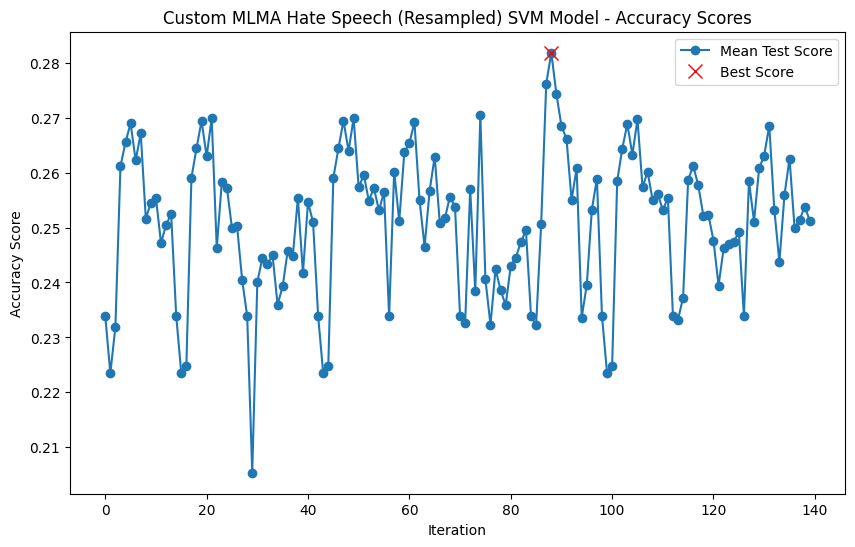

In [179]:
# Plot all accuracy scores for the custom SVM model
plt.figure(figsize=(10, 6))
plt.plot(mlma_hate_speech_custom_svm_grid_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot a red x at the maximum accuracy score
best_mlma_hate_speech_custom_svm_score_index = np.argmax(mlma_hate_speech_custom_svm_grid_search.cv_results_['mean_test_score'])
plt.plot(best_mlma_hate_speech_custom_svm_score_index, mlma_hate_speech_custom_svm_grid_search.cv_results_['mean_test_score'][best_mlma_hate_speech_custom_svm_score_index], 'rx', markersize=10, label='Best Score')

plt.title(f'Custom MLMA Hate Speech ({balance}) SVM Model - Accuracy Scores')
plt.xlabel('Iteration')
plt.ylabel('Accuracy Score')
plt.legend()
plt.show()

In [180]:
# Print the best parameters and score from the grid search
print("Best parameters for SVM with linear kernel and L1 penalty:")
pprint(mlma_hate_speech_custom_svm_grid_search.best_params_)
print("Best score for SVM with linear kernel and L1 penalty:")
print(mlma_hate_speech_custom_svm_grid_search.best_score_)

# Best custom kernel
best_mlma_hate_speech_custom_kernel = mlma_hate_speech_custom_svm_grid_search.best_params_['kernel']

Best parameters for SVM with linear kernel and L1 penalty:
{'C': np.float64(0.7000000000000001),
 'class_weight': None,
 'kernel': 'linear',
 'max_iter': 5}
Best score for SVM with linear kernel and L1 penalty:
0.28183391003460206


In [181]:
# Train the SVM model with the best parameters
mlma_hate_speech_custom_svm_best_params = mlma_hate_speech_custom_svm_grid_search.best_params_.copy()
mlma_hate_speech_custom_svm_best_params.pop('kernel', None) # Remove the kernel key if it exists
mlma_hate_speech_custom_svm_best_model = svm.LinearSVC(**mlma_hate_speech_custom_svm_best_params, random_state=42)
mlma_hate_speech_custom_svm_best_model.fit(mlma_hate_speech_X_train, mlma_hate_speech_y_train)

LinearSVC(C=np.float64(0.7000000000000001), max_iter=5, random_state=42)

In [182]:
# Use the model to make predictions on the test set
mlma_hate_speech_custom_y_pred = mlma_hate_speech_custom_svm_best_model.predict(mlma_hate_speech_X_test)

# Print the classification report
print("Classification report for MLMA Hate Speech Dataset with L1 regularization:")
print(classification_report(mlma_hate_speech_y_test, mlma_hate_speech_custom_y_pred))

Classification report for MLMA Hate Speech Dataset with L1 regularization:
              precision    recall  f1-score   support

           0       0.40      0.53      0.45      1084
           1       0.33      0.27      0.30      1084
           2       0.37      0.11      0.17      1084
           3       0.46      0.72      0.56      1084

    accuracy                           0.41      4336
   macro avg       0.39      0.41      0.37      4336
weighted avg       0.39      0.41      0.37      4336



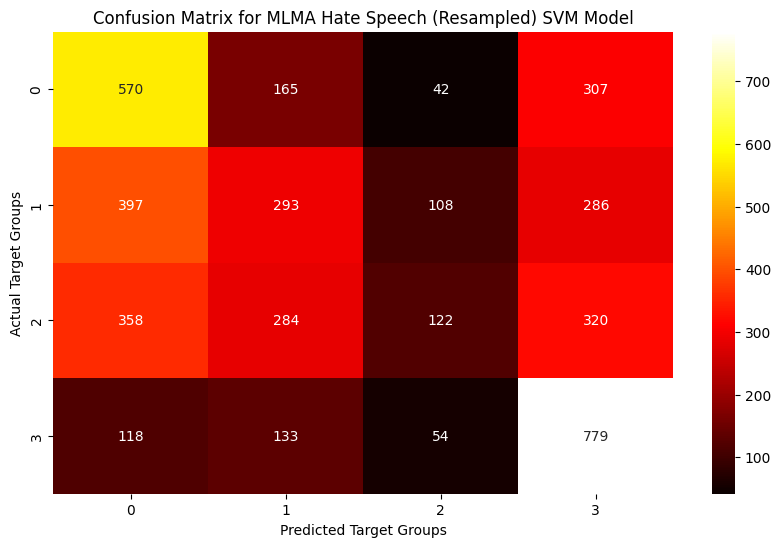

In [183]:
# Plot a heatmap of the predicted vs actual HOF levels
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(mlma_hate_speech_y_test, mlma_hate_speech_custom_y_pred, rownames=['Actual Target Groups'], colnames=['Predicted Target Groups']), annot=True, fmt='d', cmap='hot')
plt.title(f'Confusion Matrix for MLMA Hate Speech ({balance}) SVM Model')
plt.show()

,feature,importance_mean,importance_std
0,implicit,0.044673,0.002609
1,explicit,0.044673,0.002609
2,annotator_sentiment,0.042251,0.003220
3,abuse_level,0.002629,0.002630


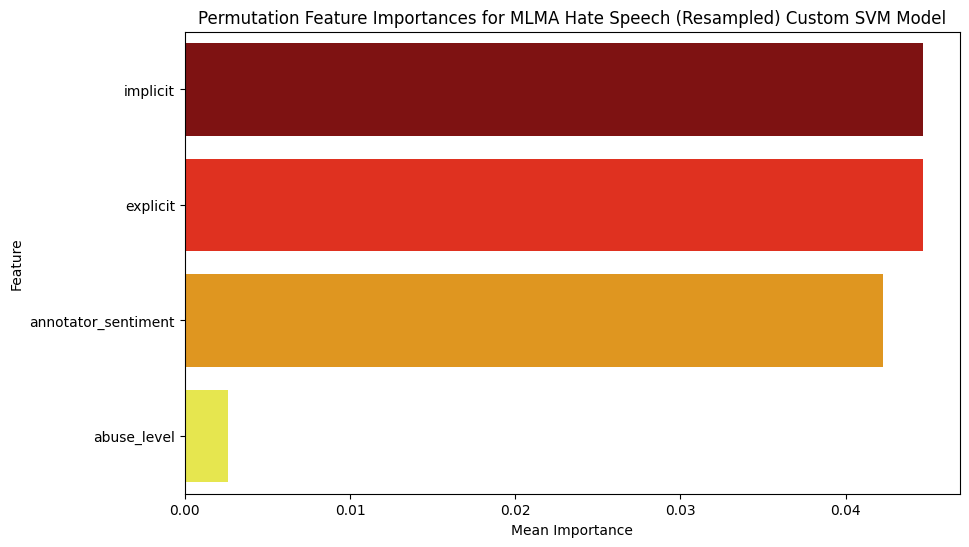

In [184]:
from sklearn.inspection import permutation_importance

# Determine the feature importances using permutation importance
perm_importance = permutation_importance(mlma_hate_speech_custom_svm_best_model, mlma_hate_speech_X_test, mlma_hate_speech_y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Organize the results into a DataFrame
mlma_hate_speech_custom_svm_model_perm_importances = pd.DataFrame({
    'feature': mlma_hate_speech_X_test.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

display(mlma_hate_speech_custom_svm_model_perm_importances)

# Condense into a dictionary with each feature key and importance mean value
mlma_hate_speech_custom_svm_model_perm_importances_dict = mlma_hate_speech_custom_svm_model_perm_importances.set_index('feature')['importance_mean'].to_dict()

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance_mean', y='feature', data=mlma_hate_speech_custom_svm_model_perm_importances, palette='hot')
plt.title(f'Permutation Feature Importances for MLMA Hate Speech ({balance}) Custom SVM Model')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.show()

In [185]:
# Get the custom model's accuracy and f1-score
mlma_hate_speech_custom_accuracy = accuracy_score(mlma_hate_speech_y_test, mlma_hate_speech_custom_y_pred)
mlma_hate_speech_custom_f1_score = f1_score(mlma_hate_speech_y_test, mlma_hate_speech_custom_y_pred, average='weighted')
print(f"Custom SVM Model Accuracy: {mlma_hate_speech_custom_accuracy}")
print(f"Custom SVM Model F1-Score: {mlma_hate_speech_custom_f1_score}")

Custom SVM Model Accuracy: 0.40682656826568264
Custom SVM Model F1-Score: 0.371137217083475


In [186]:
svm_classification_results_list.append(("MLMA Hate Speech", best_mlma_hate_speech_custom_kernel, "L1", mlma_hate_speech_custom_accuracy, mlma_hate_speech_custom_f1_score, mlma_hate_speech_custom_svm_model_perm_importances_dict))

In [187]:
svm_classification_results_list

[('Convabuse',
  'Linear',
  'L1',
  0.535678791492745,
  0.5138186780532034,
  {'system': 0.11788908765652953,
   'implicit': 0.10230570463128603,
   'explicit': 0.0796660703637448,
   'bot': 0.043589743589743594,
   'annotator_id': 0.01612005565493938,
   'generalised': 0.0,
   'individual': 0.0,
   'target_groups': -0.004830053667262968}),
 ('Convabuse',
  'RBF',
  'L2',
  0.5358775591333731,
  0.519119606435703,
  {'system': 0.22393162393162394,
   'explicit': 0.08547008547008547,
   'target_groups': 0.06022659511031606,
   'implicit': 0.058437686344663106,
   'annotator_id': 0.0385012919896641,
   'bot': 0.03172331544424567,
   'individual': 0.0,
   'generalised': 0.0}),
 ('Convabuse',
  'linear',
  'L1',
  0.4259590538660306,
  0.3676610685029406,
  {'system': 0.1969787318624528,
   'implicit': 0.06692506459948319,
   'individual': 0.0,
   'generalised': 0.0,
   'bot': -0.015026833631484798,
   'explicit': -0.015941164778374074,
   'target_groups': -0.02675412442854303,
   'annot

## Support Vector Machine Conclusions

In [188]:
# Convert the svm_results_list to a DataFrame
svm_classification_summary = pd.DataFrame(svm_classification_results_list, columns=["Dataset", "Kernel", "Regularization", "Accuracy", "F1 Score", "Permutation Importances"])
svm_classification_summary["Balance"] = "SMOTE"
svm_classification_summary["Model"] = "Support Vector Machine"
svm_classification_summary

,Dataset,Kernel,Regularization,Accuracy,F1 Score,Permutation Importances,Balance,Model
0,Convabuse,Linear,L1,0.535679,0.513819,"{'system': 0.11788908765652953, 'implicit': 0....",SMOTE,Support Vector Machine
1,Convabuse,RBF,L2,0.535878,0.519120,"{'system': 0.22393162393162394, 'explicit': 0....",SMOTE,Support Vector Machine
2,Convabuse,linear,L1,0.425959,0.367661,"{'system': 0.1969787318624528, 'implicit': 0.0...",SMOTE,Support Vector Machine
3,Dynamically Generated Hate Speech,Linear,L1,0.836848,0.832386,"{'type': 0.33510806536636795, 'annotator': 0.0...",SMOTE,Support Vector Machine
4,Dynamically Generated Hate Speech,RBF,L2,0.738535,0.736685,"{'type': 0.18302583025830263, 'target_groups':...",SMOTE,Support Vector Machine
5,Dynamically Generated Hate Speech,poly,L1,0.545730,0.522752,"{'original': 0.029467580390089666, 'type': 0.0...",SMOTE,Support Vector Machine
6,Online Abusive Attacks,Linear,L1,0.836848,0.832386,"{'type': 0.33510806536636795, 'annotator': 0.0...",SMOTE,Support Vector Machine
7,Online Abusive Attacks,RBF,L2,0.477518,0.412589,"{'Toxic parent tweets': 0.2201438848920863, 'T...",SMOTE,Support Vector Machine
8,Online Abusive Attacks,rbf,L1,0.571043,0.560432,"{'Toxic parent tweets': 0.33543165467625896, '...",SMOTE,Support Vector Machine
9,US Elections 2020 Election Hate Speech,Linear,L1,0.643939,0.643939,"{'Biden': 0.11268939393939395, 'Trump': 0.0693...",SMOTE,Support Vector Machine


In [189]:
svm_classification_summary.to_csv("/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/results/model5_svm-classification-summary_resampled.csv", index=False)